# Newmatrix Phase 1 + Phase 2 Notebook

This notebook implements:
- **Phase 1**: Baseline simulations on `newmatrix` for:
  - Parallel (flooding)
  - Serial (emulated via one-check clusters)
  - Layered BP (round-robin cluster schedule)
  - Residual-based cluster scheduling
- **Phase 2**: Validation hooks for new RL state-space environments:
  - Discretized LLR
  - Discretized residual
  - Discretized tanh(LLR)
  - Discretized mutual information

In [18]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix

# Ensure project root is importable
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from ldpc.bp_decoder import BpDecoder
from utils.awgn_channel import AWGNChannel
from utils.res_cluster_picker import pick_max_avg_residual_cluster

In [19]:
# Paths
H_NPY = os.path.join(ROOT, 'newmatrix', 'PCM_802_16e_R12_z48.npy')
H_CSV = os.path.join(ROOT, 'newmatrix', 'PCM_802_16e_R12_z48.csv')

# Load parity-check matrix from .npy (preferred), fallback to .csv
if os.path.exists(H_NPY):
    H_dense = np.load(H_NPY)
else:
    H_dense = np.loadtxt(H_CSV, delimiter=',')

H_dense = (H_dense != 0).astype(np.uint8)
H = csr_matrix(H_dense)
m, n_code = H.shape
rate_est = 1 - (m / n_code)

print(f'H shape: {H.shape}')
print(f'Estimated rate (1 - m/n): {rate_est:.4f}')

H shape: (576, 1152)
Estimated rate (1 - m/n): 0.5000


## Simulation Configuration
Adjust `N_FRAMES` and `MAX_SWEEPS` based on runtime budget.

In [25]:
SNR_DB_LIST = [-3, -2, -1, 0, 1, 2, 3]
N_FRAMES = 50
MAX_SWEEPS = 5
CLUSTER_SIZES = [24, 48]
SEED = 7

assert all(m % cs == 0 for cs in CLUSTER_SIZES), 'Each cluster size must divide m exactly.'

rng = np.random.default_rng(SEED)

# Serial schedule (one check per action)
serial_clusters = [np.array([i], dtype=np.int32) for i in range(m)]

print(f'N_FRAMES={N_FRAMES}, MAX_SWEEPS={MAX_SWEEPS}')
print(f'Serial emulated clusters: {len(serial_clusters)} (size 1 each)')
for cs in CLUSTER_SIZES:
    print(f'Cluster size {cs}: num_clusters={m // cs}')

N_FRAMES=50, MAX_SWEEPS=5
Serial emulated clusters: 576 (size 1 each)
Cluster size 24: num_clusters=24
Cluster size 48: num_clusters=12


In [26]:
def make_channel_llr_zero_codeword(n_frames, n, snr_db):
    # All-zero codeword => BPSK all +1
    tx = np.ones((n_frames, n), dtype=np.float64)
    llrs = AWGNChannel(tx, snr_db=snr_db)
    return llrs


def parity_ok(H_csr, hard_bits):
    syndrome = H_csr @ hard_bits % 2
    return np.all(syndrome == 0), int(np.sum(syndrome))


def make_layered_clusters(cluster_size):
    if m % cluster_size != 0:
        raise ValueError(f'cluster_size={cluster_size} must divide m={m}')
    num_clusters = m // cluster_size
    check_indices = np.arange(m)
    clusters_2d = check_indices.reshape(num_clusters, cluster_size)
    return [row.astype(np.int32) for row in clusters_2d], num_clusters


def decode_parallel(decoder, llr, max_sweeps):
    # Flooding / parallel schedule (max_iter is set when decoder is constructed)
    decoded = decoder.decode(llr)
    return decoded.astype(np.uint8), max_sweeps


def decode_cluster_schedule(decoder, llr, clusters, total_actions, mode='round_robin'):
    decoder.reset()
    decoder.initialise_log_domain_bp(llr)

    last_llr = llr
    actions_used = 0

    for t in range(total_actions):
        if mode == 'round_robin':
            idx = t % len(clusters)
            chosen_cluster = clusters[idx]
        elif mode == 'residual':
            residuals = decoder.get_residuals()
            idx, chosen_cluster = pick_max_avg_residual_cluster(residuals, clusters)
            if chosen_cluster is None:
                break
        else:
            raise ValueError(f'Unknown mode: {mode}')

        last_llr = decoder.decode_cluster(chosen_cluster)
        actions_used += 1

        hard = (last_llr < 0).astype(np.uint8)
        ok, _ = parity_ok(H, hard)
        if ok:
            break

    decoded = (last_llr < 0).astype(np.uint8)
    return decoded, actions_used


def run_method(method_name, snr_list, n_frames, max_sweeps, cluster_size):
    rows = []
    layered_clusters, num_clusters = make_layered_clusters(cluster_size)
    avg_layered_cluster_size = float(np.mean([len(c) for c in layered_clusters]))

    for snr in snr_list:
        llr_batch = make_channel_llr_zero_codeword(n_frames=n_frames, n=n_code, snr_db=snr)

        bit_errors = 0
        frame_errors = 0
        total_iters = 0
        total_check_updates = 0

        for i in range(n_frames):
            llr = llr_batch[i]
            decoder = BpDecoder(H, max_iter=max_sweeps)

            if method_name == 'parallel':
                decoded, iters_used = decode_parallel(decoder, llr, max_sweeps=max_sweeps)
                updates = iters_used * m
            elif method_name == 'layered':
                total_actions = max_sweeps * len(layered_clusters)
                decoded, actions_used = decode_cluster_schedule(
                    decoder, llr, layered_clusters, total_actions, mode='round_robin'
                )
                iters_used = actions_used / len(layered_clusters)
                updates = int(actions_used * avg_layered_cluster_size)
            elif method_name == 'residual':
                total_actions = max_sweeps * len(layered_clusters)
                decoded, actions_used = decode_cluster_schedule(
                    decoder, llr, layered_clusters, total_actions, mode='residual'
                )
                iters_used = actions_used / len(layered_clusters)
                updates = int(actions_used * avg_layered_cluster_size)
            elif method_name == 'serial_emulated':
                total_actions = max_sweeps * len(serial_clusters)
                decoded, actions_used = decode_cluster_schedule(
                    decoder, llr, serial_clusters, total_actions, mode='round_robin'
                )
                iters_used = actions_used / len(serial_clusters)
                updates = actions_used
            else:
                raise ValueError(f'Unknown method {method_name}')

            errors = int(np.sum(decoded != 0))
            bit_errors += errors
            frame_errors += int(errors > 0)
            total_iters += iters_used
            total_check_updates += updates

        ber = bit_errors / (n_frames * n_code)
        fer = frame_errors / n_frames

        rows.append({
            'method': method_name,
            'cluster_size': cluster_size,
            'num_clusters': num_clusters,
            'snr_db': snr,
            'ber': ber,
            'fer': fer,
            'avg_sweeps_used': total_iters / n_frames,
            'avg_check_updates': total_check_updates / n_frames,
            'n_frames': n_frames
        })

        print(
            f'[{method_name} | cs={cluster_size}] SNR={snr:>2} dB | '
            f'BER={ber:.6e} | FER={fer:.4f} | avg_updates={total_check_updates/n_frames:.1f}'
        )

    return pd.DataFrame(rows)

In [27]:
methods = ['parallel', 'serial_emulated', 'layered', 'residual']
all_results = []

for cluster_size in CLUSTER_SIZES:
    print('\n' + '=' * 70)
    print(f'Running cluster_size={cluster_size} (num_clusters={m // cluster_size})')
    print('=' * 70)
    for method in methods:
        df_m = run_method(method, SNR_DB_LIST, N_FRAMES, MAX_SWEEPS, cluster_size=cluster_size)
        all_results.append(df_m)

results_df = pd.concat(all_results, ignore_index=True)
results_df = results_df.sort_values(['cluster_size', 'method', 'snr_db']).reset_index(drop=True)
results_df


Running cluster_size=24 (num_clusters=24)
[parallel | cs=24] SNR=-3 dB | BER=1.043750e-01 | FER=1.0000 | avg_updates=2880.0
[parallel | cs=24] SNR=-2 dB | BER=6.145833e-02 | FER=1.0000 | avg_updates=2880.0
[parallel | cs=24] SNR=-1 dB | BER=2.779514e-02 | FER=1.0000 | avg_updates=2880.0
[parallel | cs=24] SNR= 0 dB | BER=1.140625e-02 | FER=1.0000 | avg_updates=2880.0
[parallel | cs=24] SNR= 1 dB | BER=4.166667e-03 | FER=0.8200 | avg_updates=2880.0
[parallel | cs=24] SNR= 2 dB | BER=8.333333e-04 | FER=0.4200 | avg_updates=2880.0
[parallel | cs=24] SNR= 3 dB | BER=3.125000e-04 | FER=0.1400 | avg_updates=2880.0
[serial_emulated | cs=24] SNR=-3 dB | BER=9.826389e-02 | FER=1.0000 | avg_updates=2880.0
[serial_emulated | cs=24] SNR=-2 dB | BER=5.157986e-02 | FER=1.0000 | avg_updates=2880.0
[serial_emulated | cs=24] SNR=-1 dB | BER=2.343750e-02 | FER=1.0000 | avg_updates=2880.0
[serial_emulated | cs=24] SNR= 0 dB | BER=8.350694e-03 | FER=0.9200 | avg_updates=2767.9
[serial_emulated | cs=24] S

,method,cluster_size,num_clusters,snr_db,ber,fer,avg_sweeps_used,avg_check_updates,n_frames
0,layered,24,24,-3,0.103438,1.00,5.000000,2880.00,50
1,layered,24,24,-2,0.050243,1.00,5.000000,2880.00,50
2,layered,24,24,-1,0.020104,1.00,4.994167,2876.64,50
3,layered,24,24,0,0.008802,0.96,4.773333,2749.44,50
4,layered,24,24,1,0.002969,0.70,3.478333,2003.52,50
5,layered,24,24,2,0.000642,0.28,1.964167,1131.36,50
6,layered,24,24,3,0.000382,0.18,1.280000,737.28,50
7,parallel,24,24,-3,0.104375,1.00,5.000000,2880.00,50
8,parallel,24,24,-2,0.061458,1.00,5.000000,2880.00,50
9,parallel,24,24,-1,0.027795,1.00,5.000000,2880.00,50


In [28]:
from pathlib import Path

BASE_OUTPUT_DIR = Path(ROOT) / 'RL' / 'results' / 'newmatrix'
baseline_dir = BASE_OUTPUT_DIR / 'baselines' / f'frames_{N_FRAMES}'
baseline_dir.mkdir(parents=True, exist_ok=True)

combined_baseline_csv = baseline_dir / 'baseline_all.csv'
results_df.to_csv(combined_baseline_csv, index=False)

for cluster_size, df_cs in results_df.groupby('cluster_size'):
    cs_dir = baseline_dir / f'cluster_{int(cluster_size)}'
    cs_dir.mkdir(parents=True, exist_ok=True)
    df_cs.to_csv(cs_dir / 'baseline_metrics.csv', index=False)

print(f'Baseline CSVs saved under: {baseline_dir}')
print(f'Combined: {combined_baseline_csv}')

Baseline CSVs saved under: /root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/baselines/frames_50
Combined: /root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/baselines/frames_50/baseline_all.csv


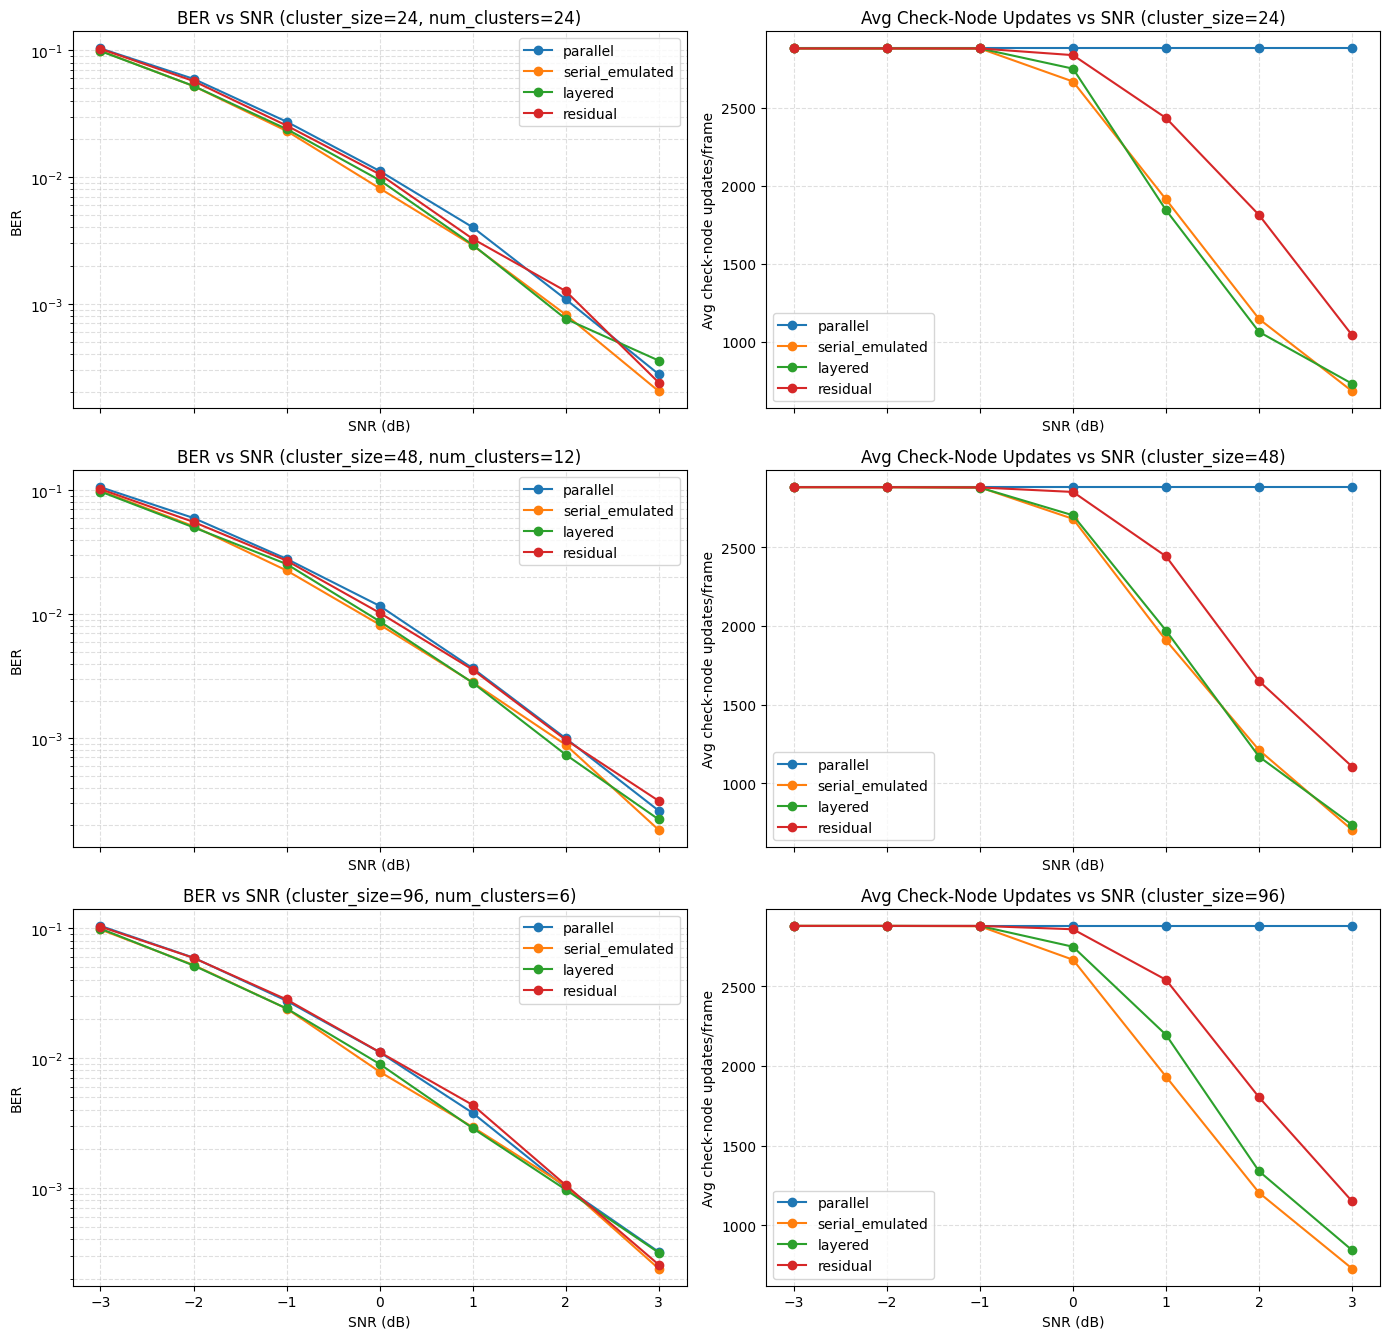

In [23]:
fig, axes = plt.subplots(len(CLUSTER_SIZES), 2, figsize=(14, 4.5 * len(CLUSTER_SIZES)), sharex=True)

if len(CLUSTER_SIZES) == 1:
    axes = np.array([axes])

for row_idx, cluster_size in enumerate(CLUSTER_SIZES):
    df_cs = results_df[results_df['cluster_size'] == cluster_size]
    pivot_ber = df_cs.pivot(index='snr_db', columns='method', values='ber')
    pivot_updates = df_cs.pivot(index='snr_db', columns='method', values='avg_check_updates')

    for method in methods:
        axes[row_idx, 0].semilogy(pivot_ber.index, pivot_ber[method], marker='o', label=method)
    axes[row_idx, 0].set_title(f'BER vs SNR (cluster_size={cluster_size}, num_clusters={m // cluster_size})')
    axes[row_idx, 0].set_xlabel('SNR (dB)')
    axes[row_idx, 0].set_ylabel('BER')
    axes[row_idx, 0].grid(True, which='both', ls='--', alpha=0.4)
    axes[row_idx, 0].legend()

    for method in methods:
        axes[row_idx, 1].plot(pivot_updates.index, pivot_updates[method], marker='o', label=method)
    axes[row_idx, 1].set_title(f'Avg Check-Node Updates vs SNR (cluster_size={cluster_size})')
    axes[row_idx, 1].set_xlabel('SNR (dB)')
    axes[row_idx, 1].set_ylabel('Avg check-node updates/frame')
    axes[row_idx, 1].grid(True, ls='--', alpha=0.4)
    axes[row_idx, 1].legend()

plt.tight_layout()
plt.show()

## Phase 2 Validation: New Discretized RL State Spaces
This cell checks that all new environment IDs can be instantiated on `newmatrix` with `codeword_mode='all_zero'`.

In [24]:
import gymnasium as gym
import gymnasium_env_2

H_PATH = os.path.join(ROOT, 'newmatrix', 'PCM_802_16e_R12_z48.npy')

env_ids = [
    'gymnasium_env_2/LDPC-DiscreteLLR-v0',
    'gymnasium_env_2/LDPC-DiscreteResidual-v0',
    'gymnasium_env_2/LDPC-DiscreteTanhLLR-v0',
    'gymnasium_env_2/LDPC-DiscreteMI-v0',
]

for cluster_size in CLUSTER_SIZES:
    num_clusters = m // cluster_size
    print(f'\n--- cluster_size={cluster_size}, num_clusters={num_clusters} ---')

    for env_id in env_ids:
        env = gym.make(
            env_id,
            H_path=H_PATH,
            num_clusters=num_clusters,
            max_iterations=30,
            snr_db=0.0,
            codeword_mode='all_zero',
            bins=8,
        )

        obs, info = env.reset(seed=42)
        action = env.action_space.sample()
        obs2, reward, terminated, truncated, info2 = env.step(action)

        print(
            f'{env_id}: obs_shape={obs.shape}, reward={reward:.4f}, terminated={terminated}'
        )
        env.close()


--- cluster_size=24, num_clusters=24 ---
gymnasium_env_2/LDPC-DiscreteLLR-v0: obs_shape=(26,), reward=1.1806, terminated=False
gymnasium_env_2/LDPC-DiscreteResidual-v0: obs_shape=(26,), reward=1.1121, terminated=False
gymnasium_env_2/LDPC-DiscreteTanhLLR-v0: obs_shape=(26,), reward=1.0930, terminated=False
gymnasium_env_2/LDPC-DiscreteMI-v0: obs_shape=(26,), reward=1.1121, terminated=False

--- cluster_size=48, num_clusters=12 ---
gymnasium_env_2/LDPC-DiscreteLLR-v0: obs_shape=(14,), reward=1.0837, terminated=False
gymnasium_env_2/LDPC-DiscreteResidual-v0: obs_shape=(14,), reward=1.0883, terminated=False
gymnasium_env_2/LDPC-DiscreteTanhLLR-v0: obs_shape=(14,), reward=1.2833, terminated=False
gymnasium_env_2/LDPC-DiscreteMI-v0: obs_shape=(14,), reward=1.1219, terminated=False

--- cluster_size=96, num_clusters=6 ---
gymnasium_env_2/LDPC-DiscreteLLR-v0: obs_shape=(8,), reward=1.1638, terminated=False
gymnasium_env_2/LDPC-DiscreteResidual-v0: obs_shape=(8,), reward=1.1638, terminated=Fa

## RL Experiments (Smoke Test First)
This section trains/evaluates RL policies for cluster sizes 24 and 48, and saves organized CSV outputs.

In [40]:
import time
from pathlib import Path
from stable_baselines3 import PPO, DQN
from stable_baselines3.common.vec_env import DummyVecEnv

RL_ENV_IDS = [
    'gymnasium_env_2/LDPC-DiscreteResidual-v0',
    'gymnasium_env_2/LDPC-DiscreteMI-v0',
]
RL_ALGOS = ['ppo', 'dqn']
RL_TRAIN_TIMESTEPS = 20000  # increased run to test non-trivial policy emergence
RL_EVAL_FRAMES = 50
RL_SNR_LIST = SNR_DB_LIST

BASE_OUTPUT_DIR = Path(ROOT) / 'RL' / 'results' / 'newmatrix'
rl_dir = BASE_OUTPUT_DIR / 'rl' / f'frames_{RL_EVAL_FRAMES}'
smoke_dir = rl_dir / 'smoke'
models_dir = rl_dir / 'models'
eval_dir = rl_dir / 'eval'
for d in [rl_dir, smoke_dir, models_dir, eval_dir]:
    d.mkdir(parents=True, exist_ok=True)

ALGO_MAP = {
    'ppo': PPO,
    'dqn': DQN,
}

def make_ldpc_env(env_id, cluster_size, snr_db=0.0):
    num_clusters = m // cluster_size
    env_max_iterations = MAX_SWEEPS * num_clusters
    return gym.make(
        env_id,
        H_path=H_PATH,
        num_clusters=num_clusters,
        max_iterations=env_max_iterations,
        snr_db=snr_db,
        codeword_mode='all_zero',
        bins=8,
    )

def train_model(env_id, algo_name, cluster_size, timesteps, seed):
    def _build_env():
        return make_ldpc_env(env_id, cluster_size=cluster_size, snr_db=0.0)

    vec_env = DummyVecEnv([_build_env])
    model_cls = ALGO_MAP[algo_name]

    if algo_name == 'ppo':
        model = model_cls(
            'MlpPolicy',
            vec_env,
            verbose=0,
            seed=seed,
            n_steps=256,
            batch_size=64,
            device='cpu',
        )
    elif algo_name == 'dqn':
        model = model_cls(
            'MlpPolicy',
            vec_env,
            verbose=0,
            seed=seed,
            learning_starts=100,
            buffer_size=5000,
            batch_size=64,
            train_freq=4,
            gradient_steps=1,
            exploration_fraction=0.3,
            device='cpu',
        )
    else:
        raise ValueError(f'Unsupported algo: {algo_name}')

    t0 = time.time()
    model.learn(total_timesteps=timesteps, progress_bar=False)
    train_seconds = time.time() - t0
    vec_env.close()
    return model, train_seconds

def evaluate_model(model, env_id, cluster_size, snr_db, n_frames, seed):
    env = make_ldpc_env(env_id, cluster_size=cluster_size, snr_db=snr_db)

    total_bit_errors = 0
    total_frame_errors = 0
    total_rewards = 0.0
    total_actions = 0

    for ep in range(n_frames):
        obs, info = env.reset(seed=seed + ep)
        ep_reward = 0.0

        for step in range(env.unwrapped.max_iterations):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            ep_reward += float(reward)
            if terminated or truncated:
                break

        decoded_bits = (env.unwrapped.current_llr < 0).astype(np.uint8)
        target_bits = env.unwrapped.encoded_codeword.astype(np.uint8)
        bit_errors = int(np.count_nonzero(decoded_bits != target_bits))

        total_bit_errors += bit_errors
        total_frame_errors += int(bit_errors > 0)
        total_rewards += ep_reward
        total_actions += info.get('iteration', 0)

    env.close()

    ber = total_bit_errors / (n_frames * n_code)
    fer = total_frame_errors / n_frames
    avg_reward = total_rewards / n_frames
    avg_actions = total_actions / n_frames

    return {
        'ber': ber,
        'fer': fer,
        'avg_reward': avg_reward,
        'avg_actions': avg_actions,
        'n_frames': n_frames,
    }

print(f'RL outputs will be saved under: {rl_dir}')
print(f'RL envs: {RL_ENV_IDS}')
print(f'RL algos: {RL_ALGOS}')

RL outputs will be saved under: /root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/rl/frames_50
RL envs: ['gymnasium_env_2/LDPC-DiscreteResidual-v0', 'gymnasium_env_2/LDPC-DiscreteMI-v0']
RL algos: ['ppo', 'dqn']


In [41]:
# Smoke test (must pass before full RL run)
smoke_rows = []
SMOKE_SPEC = {
    'cluster_size': 24,
    'env_id': 'gymnasium_env_2/LDPC-DiscreteResidual-v0',
    'algo': 'ppo',
    'timesteps': 300,
    'snr_db': 0.0,
    'n_frames': 5,
}

try:
    smoke_model, smoke_train_sec = train_model(
        env_id=SMOKE_SPEC['env_id'],
        algo_name=SMOKE_SPEC['algo'],
        cluster_size=SMOKE_SPEC['cluster_size'],
        timesteps=SMOKE_SPEC['timesteps'],
        seed=SEED,
    )
    smoke_metrics = evaluate_model(
        smoke_model,
        env_id=SMOKE_SPEC['env_id'],
        cluster_size=SMOKE_SPEC['cluster_size'],
        snr_db=SMOKE_SPEC['snr_db'],
        n_frames=SMOKE_SPEC['n_frames'],
        seed=SEED,
    )

    smoke_rows.append({
        **SMOKE_SPEC,
        **smoke_metrics,
        'train_seconds': smoke_train_sec,
        'status': 'pass',
        'error': '',
    })
except Exception as e:
    smoke_rows.append({
        **SMOKE_SPEC,
        'ber': np.nan,
        'fer': np.nan,
        'avg_reward': np.nan,
        'avg_actions': np.nan,
        'n_frames': SMOKE_SPEC['n_frames'],
        'train_seconds': np.nan,
        'status': 'fail',
        'error': str(e),
    })

smoke_df = pd.DataFrame(smoke_rows)
smoke_csv = smoke_dir / 'smoke_test.csv'
smoke_df.to_csv(smoke_csv, index=False)

print(f'Smoke test CSV: {smoke_csv}')
smoke_df

Smoke test CSV: /root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/rl/frames_50/smoke/smoke_test.csv


,cluster_size,env_id,algo,timesteps,snr_db,n_frames,ber,fer,avg_reward,avg_actions,train_seconds,status,error
0,24,gymnasium_env_2/LDPC-DiscreteResidual-v0,ppo,300,0.0,5,0.077951,1.0,133.066837,120.0,1.03216,pass,


In [42]:
assert (smoke_df['status'] == 'pass').all(), 'Smoke test failed. Check smoke_test.csv before full run.'

train_rows = []
eval_rows = []

for cluster_size in CLUSTER_SIZES:
    for env_id in RL_ENV_IDS:
        env_name = env_id.split('/')[-1]
        for algo in RL_ALGOS:
            print(f"\n[RL] cluster_size={cluster_size} | env={env_name} | algo={algo}")

            model, train_seconds = train_model(
                env_id=env_id,
                algo_name=algo,
                cluster_size=cluster_size,
                timesteps=RL_TRAIN_TIMESTEPS,
                seed=SEED,
            )

            model_out_dir = models_dir / f'cluster_{cluster_size}' / algo / env_name
            model_out_dir.mkdir(parents=True, exist_ok=True)
            model_path = model_out_dir / 'model'
            model.save(str(model_path))

            train_rows.append({
                'cluster_size': cluster_size,
                'num_clusters': m // cluster_size,
                'env_id': env_id,
                'algo': algo,
                'train_timesteps': RL_TRAIN_TIMESTEPS,
                'train_seconds': train_seconds,
                'model_path': str(model_path) + '.zip',
            })

            combo_eval_rows = []
            for snr_db in RL_SNR_LIST:
                metrics = evaluate_model(
                    model,
                    env_id=env_id,
                    cluster_size=cluster_size,
                    snr_db=snr_db,
                    n_frames=RL_EVAL_FRAMES,
                    seed=SEED,
                )

                row = {
                    'cluster_size': cluster_size,
                    'num_clusters': m // cluster_size,
                    'env_id': env_id,
                    'algo': algo,
                    'snr_db': snr_db,
                    **metrics,
                }
                eval_rows.append(row)
                combo_eval_rows.append(row)

            combo_eval_df = pd.DataFrame(combo_eval_rows)
            combo_eval_dir = eval_dir / f'cluster_{cluster_size}' / algo
            combo_eval_dir.mkdir(parents=True, exist_ok=True)
            combo_eval_df.to_csv(combo_eval_dir / f'{env_name}_eval.csv', index=False)

rl_train_df = pd.DataFrame(train_rows)
rl_eval_df = pd.DataFrame(eval_rows)

rl_train_csv = rl_dir / 'train_summary.csv'
rl_eval_csv = rl_dir / 'eval_all.csv'
rl_train_df.to_csv(rl_train_csv, index=False)
rl_eval_df.to_csv(rl_eval_csv, index=False)

for cluster_size, df_cs in rl_eval_df.groupby('cluster_size'):
    cs_dir = eval_dir / f'cluster_{int(cluster_size)}'
    cs_dir.mkdir(parents=True, exist_ok=True)
    df_cs.to_csv(cs_dir / 'eval_cluster_all.csv', index=False)

print(f'RL train summary: {rl_train_csv}')
print(f'RL eval summary:  {rl_eval_csv}')
rl_eval_df.head()


[RL] cluster_size=24 | env=LDPC-DiscreteResidual-v0 | algo=ppo

[RL] cluster_size=24 | env=LDPC-DiscreteResidual-v0 | algo=dqn

[RL] cluster_size=24 | env=LDPC-DiscreteMI-v0 | algo=ppo

[RL] cluster_size=24 | env=LDPC-DiscreteMI-v0 | algo=dqn

[RL] cluster_size=48 | env=LDPC-DiscreteResidual-v0 | algo=ppo

[RL] cluster_size=48 | env=LDPC-DiscreteResidual-v0 | algo=dqn

[RL] cluster_size=48 | env=LDPC-DiscreteMI-v0 | algo=ppo

[RL] cluster_size=48 | env=LDPC-DiscreteMI-v0 | algo=dqn
RL train summary: /root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/rl/frames_50/train_summary.csv
RL eval summary:  /root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/rl/frames_50/eval_all.csv


,cluster_size,num_clusters,env_id,algo,snr_db,ber,fer,avg_reward,avg_actions,n_frames
0,24,24,gymnasium_env_2/LDPC-DiscreteResidual-v0,ppo,-3,0.157656,1.0,96.390280,120.0,50
1,24,24,gymnasium_env_2/LDPC-DiscreteResidual-v0,ppo,-2,0.129392,1.0,106.768955,120.0,50
2,24,24,gymnasium_env_2/LDPC-DiscreteResidual-v0,ppo,-1,0.103628,1.0,118.288095,120.0,50
3,24,24,gymnasium_env_2/LDPC-DiscreteResidual-v0,ppo,0,0.075938,1.0,134.572078,120.0,50
4,24,24,gymnasium_env_2/LDPC-DiscreteResidual-v0,ppo,1,0.053976,1.0,152.633730,120.0,50


## Saved Plots
Generate plots from baseline and RL outputs and save them to disk.

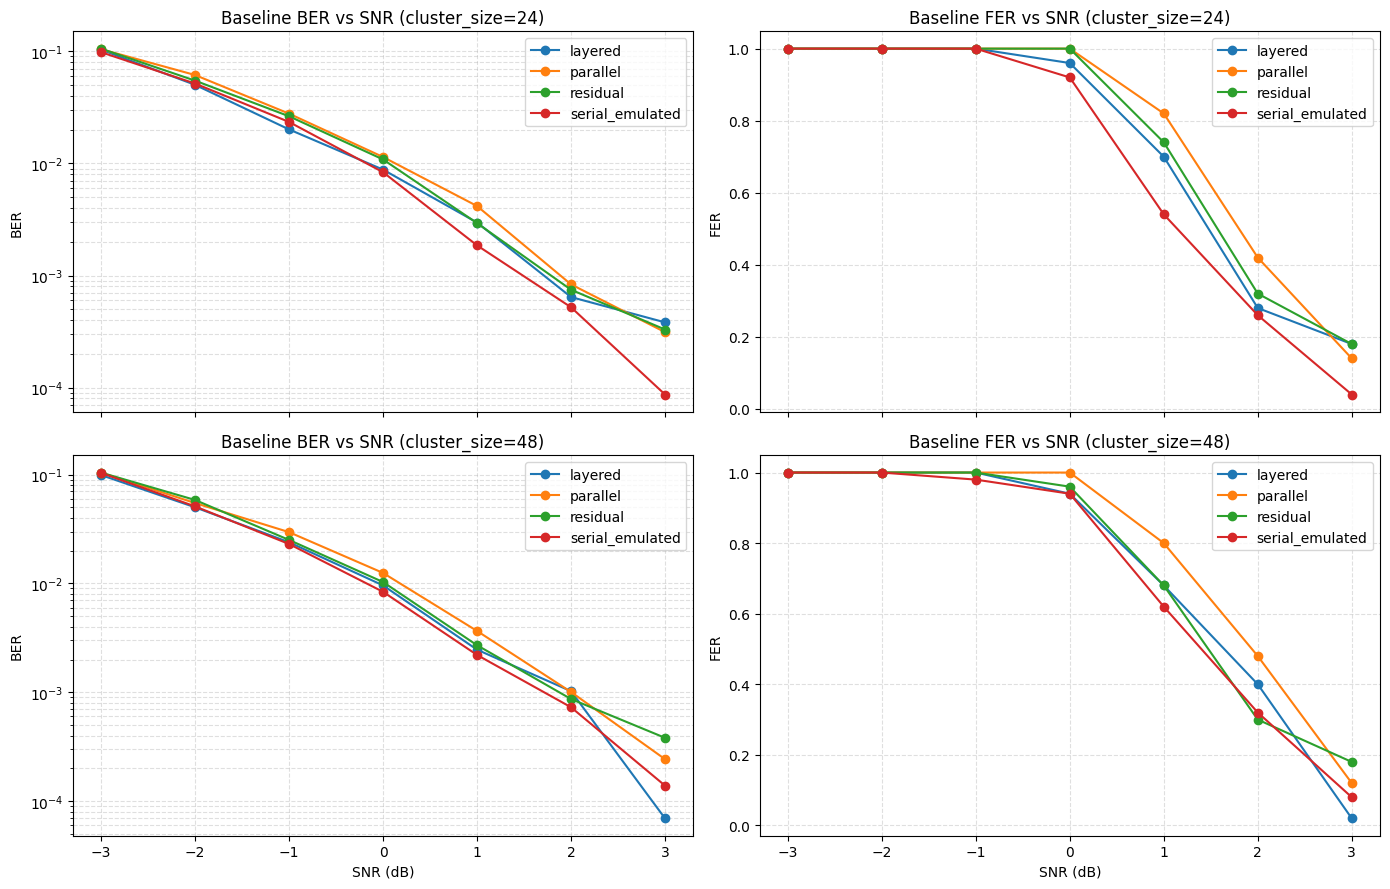

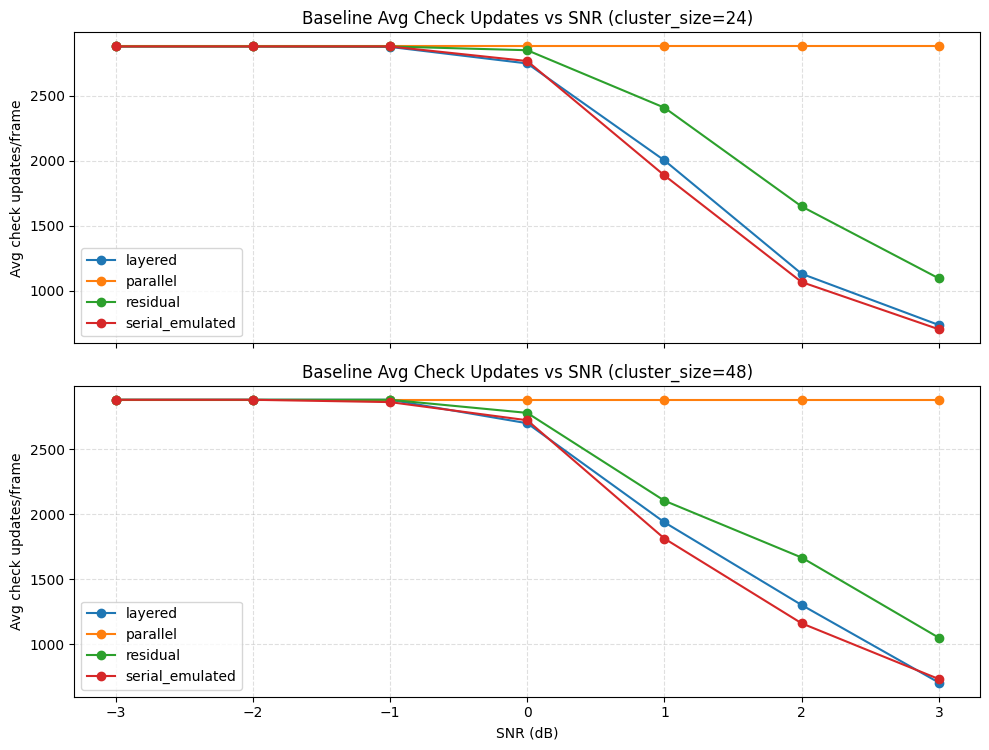

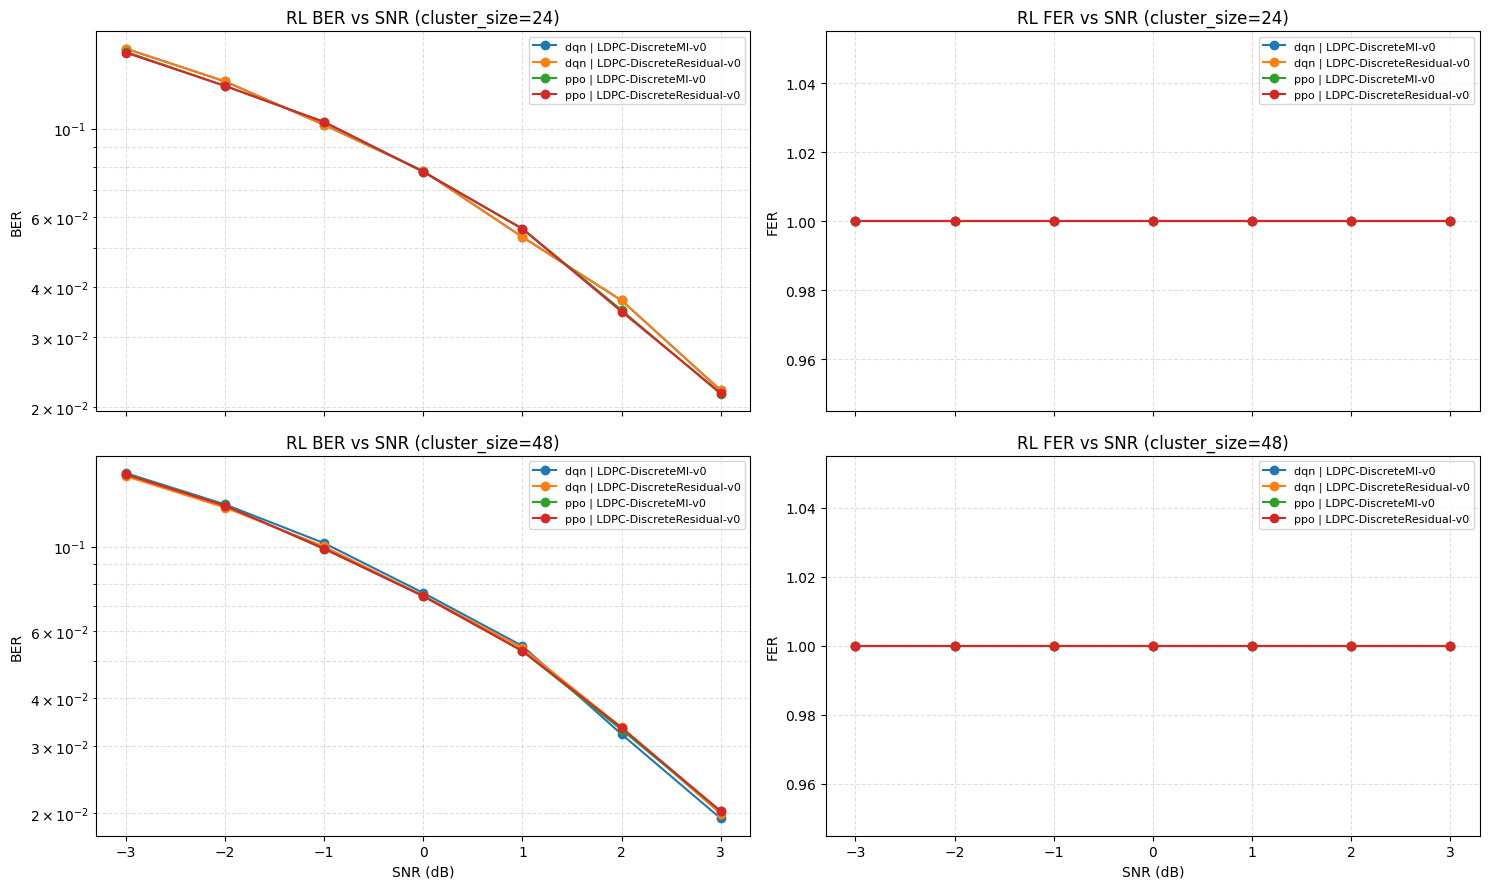

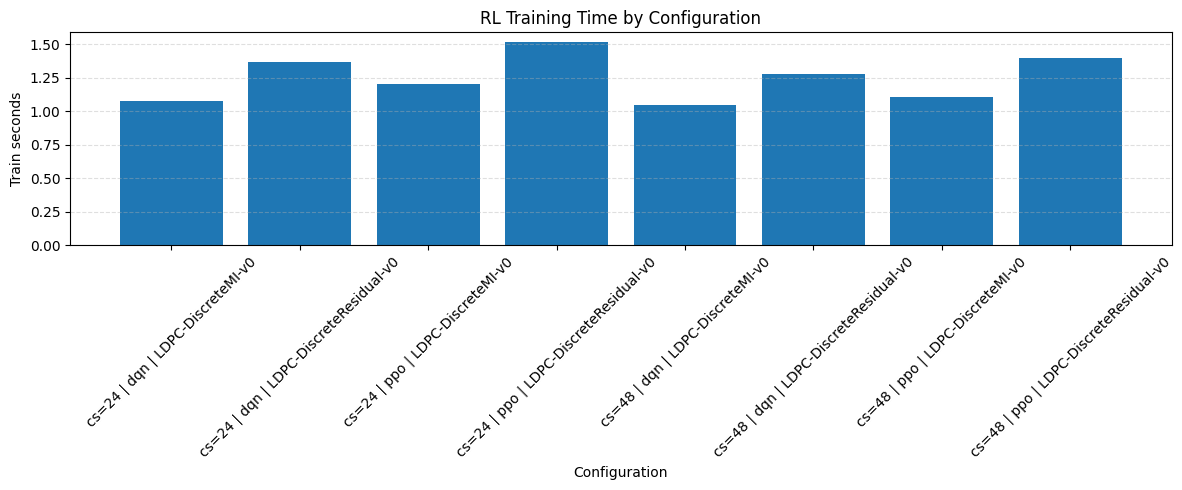

Saved plots:
- /root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/plots/frames_50_rlframes_50/baseline_ber_fer.png
- /root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/plots/frames_50_rlframes_50/baseline_updates.png
- /root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/plots/frames_50_rlframes_50/rl_ber_fer.png
- /root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/plots/frames_50_rlframes_50/rl_train_seconds.png


In [34]:
from pathlib import Path

# Reload from CSV if needed
baseline_csv_default = Path(ROOT) / 'RL' / 'results' / 'newmatrix' / 'baselines' / f'frames_{N_FRAMES}' / 'baseline_all.csv'
rl_eval_csv_default = Path(ROOT) / 'RL' / 'results' / 'newmatrix' / 'rl' / f'frames_{RL_EVAL_FRAMES}' / 'eval_all.csv'
rl_train_csv_default = Path(ROOT) / 'RL' / 'results' / 'newmatrix' / 'rl' / f'frames_{RL_EVAL_FRAMES}' / 'train_summary.csv'

if 'results_df' not in globals() or results_df is None:
    results_df = pd.read_csv(baseline_csv_default)
if 'rl_eval_df' not in globals() or rl_eval_df is None:
    rl_eval_df = pd.read_csv(rl_eval_csv_default)
if 'rl_train_df' not in globals() or rl_train_df is None:
    rl_train_df = pd.read_csv(rl_train_csv_default)

plot_dir = Path(ROOT) / 'RL' / 'results' / 'newmatrix' / 'plots' / f'frames_{N_FRAMES}_rlframes_{RL_EVAL_FRAMES}'
plot_dir.mkdir(parents=True, exist_ok=True)

# 1) Baseline BER + FER
methods_local = sorted(results_df['method'].unique().tolist())
cluster_sizes_local = sorted(results_df['cluster_size'].unique().tolist())

fig, axes = plt.subplots(len(cluster_sizes_local), 2, figsize=(14, 4.5 * len(cluster_sizes_local)), sharex=True)
if len(cluster_sizes_local) == 1:
    axes = np.array([axes])

for row_idx, cluster_size in enumerate(cluster_sizes_local):
    df_cs = results_df[results_df['cluster_size'] == cluster_size]
    pivot_ber = df_cs.pivot(index='snr_db', columns='method', values='ber')
    pivot_fer = df_cs.pivot(index='snr_db', columns='method', values='fer')

    for method in methods_local:
        axes[row_idx, 0].semilogy(pivot_ber.index, pivot_ber[method], marker='o', label=method)
    axes[row_idx, 0].set_title(f'Baseline BER vs SNR (cluster_size={cluster_size})')
    axes[row_idx, 0].set_ylabel('BER')
    axes[row_idx, 0].grid(True, which='both', ls='--', alpha=0.4)
    axes[row_idx, 0].legend()

    for method in methods_local:
        axes[row_idx, 1].plot(pivot_fer.index, pivot_fer[method], marker='o', label=method)
    axes[row_idx, 1].set_title(f'Baseline FER vs SNR (cluster_size={cluster_size})')
    axes[row_idx, 1].set_ylabel('FER')
    axes[row_idx, 1].grid(True, ls='--', alpha=0.4)
    axes[row_idx, 1].legend()

for ax in axes[-1]:
    ax.set_xlabel('SNR (dB)')

plt.tight_layout()
baseline_plot_path = plot_dir / 'baseline_ber_fer.png'
plt.savefig(baseline_plot_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

# 2) Baseline complexity plot
fig, axes = plt.subplots(len(cluster_sizes_local), 1, figsize=(10, 3.8 * len(cluster_sizes_local)), sharex=True)
if len(cluster_sizes_local) == 1:
    axes = [axes]

for row_idx, cluster_size in enumerate(cluster_sizes_local):
    df_cs = results_df[results_df['cluster_size'] == cluster_size]
    pivot_updates = df_cs.pivot(index='snr_db', columns='method', values='avg_check_updates')
    for method in methods_local:
        axes[row_idx].plot(pivot_updates.index, pivot_updates[method], marker='o', label=method)
    axes[row_idx].set_title(f'Baseline Avg Check Updates vs SNR (cluster_size={cluster_size})')
    axes[row_idx].set_ylabel('Avg check updates/frame')
    axes[row_idx].grid(True, ls='--', alpha=0.4)
    axes[row_idx].legend()

axes[-1].set_xlabel('SNR (dB)')
plt.tight_layout()
baseline_updates_path = plot_dir / 'baseline_updates.png'
plt.savefig(baseline_updates_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

# 3) RL BER + FER
rl_eval_df = rl_eval_df.copy()
rl_eval_df['env_short'] = rl_eval_df['env_id'].str.split('/').str[-1]
rl_eval_df['combo'] = rl_eval_df['algo'] + ' | ' + rl_eval_df['env_short']
cluster_sizes_rl = sorted(rl_eval_df['cluster_size'].unique().tolist())
combos = sorted(rl_eval_df['combo'].unique().tolist())

fig, axes = plt.subplots(len(cluster_sizes_rl), 2, figsize=(15, 4.5 * len(cluster_sizes_rl)), sharex=True)
if len(cluster_sizes_rl) == 1:
    axes = np.array([axes])

for row_idx, cluster_size in enumerate(cluster_sizes_rl):
    df_cs = rl_eval_df[rl_eval_df['cluster_size'] == cluster_size]
    for combo in combos:
        df_combo = df_cs[df_cs['combo'] == combo].sort_values('snr_db')
        axes[row_idx, 0].semilogy(df_combo['snr_db'], df_combo['ber'], marker='o', label=combo)
        axes[row_idx, 1].plot(df_combo['snr_db'], df_combo['fer'], marker='o', label=combo)

    axes[row_idx, 0].set_title(f'RL BER vs SNR (cluster_size={cluster_size})')
    axes[row_idx, 0].set_ylabel('BER')
    axes[row_idx, 0].grid(True, which='both', ls='--', alpha=0.4)
    axes[row_idx, 0].legend(fontsize=8)

    axes[row_idx, 1].set_title(f'RL FER vs SNR (cluster_size={cluster_size})')
    axes[row_idx, 1].set_ylabel('FER')
    axes[row_idx, 1].grid(True, ls='--', alpha=0.4)
    axes[row_idx, 1].legend(fontsize=8)

for ax in axes[-1]:
    ax.set_xlabel('SNR (dB)')

plt.tight_layout()
rl_plot_path = plot_dir / 'rl_ber_fer.png'
plt.savefig(rl_plot_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

# 4) RL training-time bars
rl_train_df = rl_train_df.copy()
rl_train_df['env_short'] = rl_train_df['env_id'].str.split('/').str[-1]
rl_train_df['label'] = ('cs=' + rl_train_df['cluster_size'].astype(str) + ' | ' + rl_train_df['algo'] + ' | ' + rl_train_df['env_short'])
rl_train_df = rl_train_df.sort_values(['cluster_size', 'algo', 'env_short'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(rl_train_df['label'], rl_train_df['train_seconds'])
ax.set_title('RL Training Time by Configuration')
ax.set_ylabel('Train seconds')
ax.set_xlabel('Configuration')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, axis='y', ls='--', alpha=0.4)
plt.tight_layout()
rl_train_plot_path = plot_dir / 'rl_train_seconds.png'
plt.savefig(rl_train_plot_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

print('Saved plots:')
print(f'- {baseline_plot_path}')
print(f'- {baseline_updates_path}')
print(f'- {rl_plot_path}')
print(f'- {rl_train_plot_path}')

## Baseline vs RL Comparison
Overlay baseline and RL BER/FER curves for direct comparison at each cluster size.

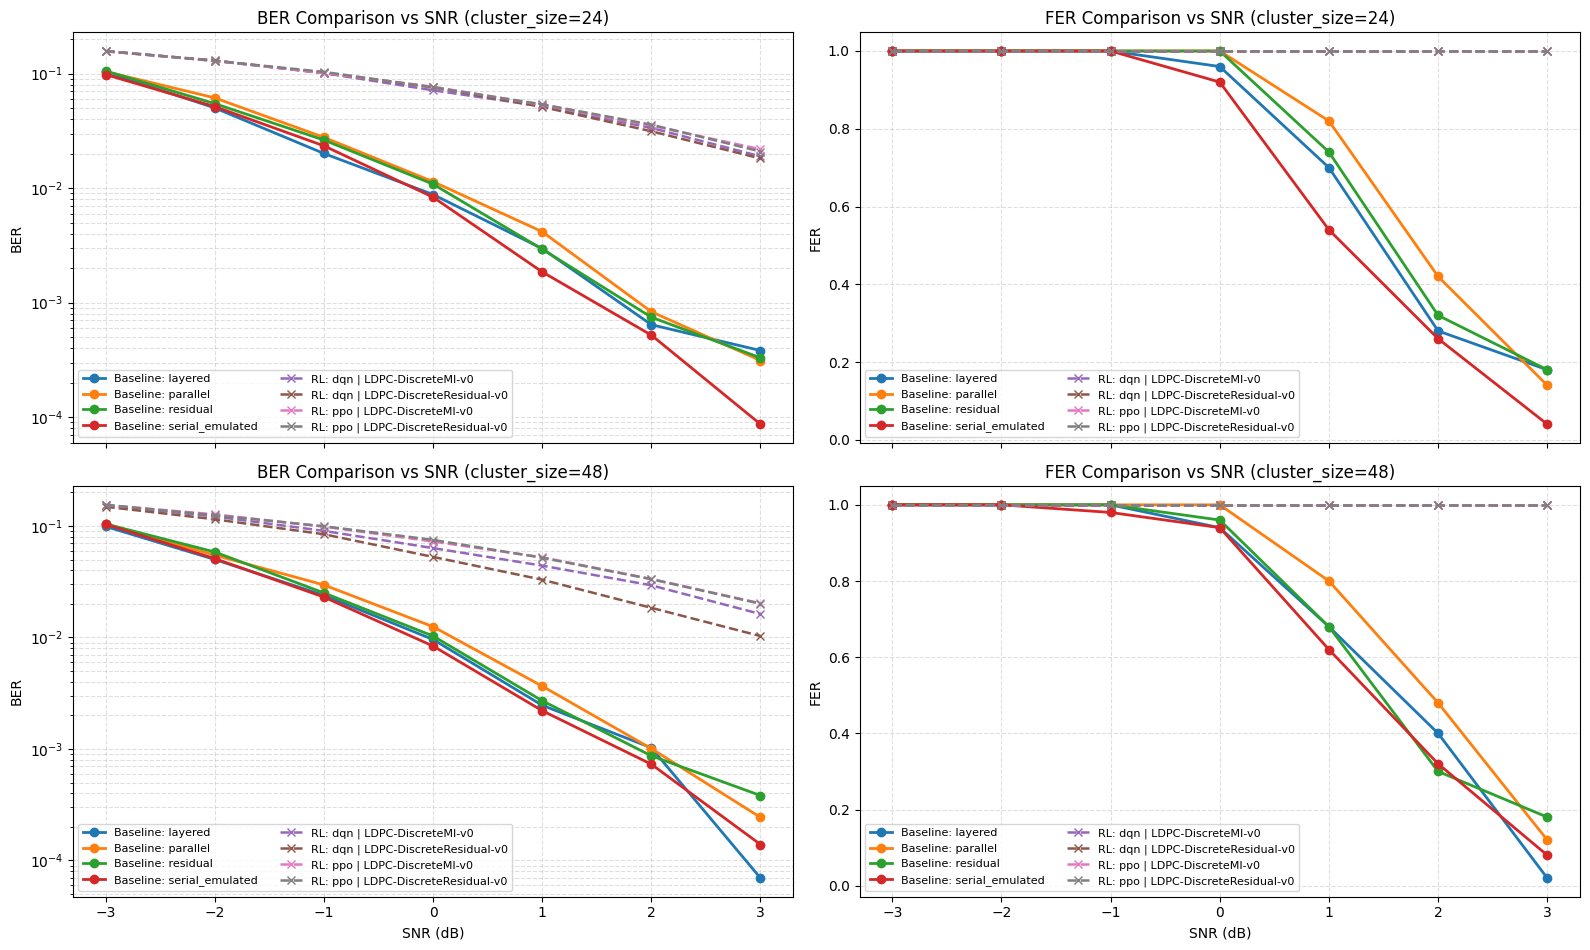

Comparison plot saved: /root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/plots/frames_50_rlframes_50/baseline_vs_rl_ber_fer.png


In [44]:
# Ensure dataframes are available (reload from CSV if needed)
if 'results_df' not in globals() or results_df is None:
    results_df = pd.read_csv(baseline_csv_default)
if 'rl_eval_df' not in globals() or rl_eval_df is None:
    rl_eval_df = pd.read_csv(rl_eval_csv_default)

baseline_plot_df = results_df.copy()
rl_plot_df = rl_eval_df.copy()
rl_plot_df['env_short'] = rl_plot_df['env_id'].str.split('/').str[-1]

cluster_sizes_cmp = sorted(set(baseline_plot_df['cluster_size']).intersection(set(rl_plot_df['cluster_size'])))
baseline_methods = sorted(baseline_plot_df['method'].unique().tolist())
rl_combos = sorted((rl_plot_df['algo'] + ' | ' + rl_plot_df['env_short']).unique().tolist())

fig, axes = plt.subplots(len(cluster_sizes_cmp), 2, figsize=(16, 4.8 * len(cluster_sizes_cmp)), sharex=True)
if len(cluster_sizes_cmp) == 1:
    axes = np.array([axes])

for row_idx, cluster_size in enumerate(cluster_sizes_cmp):
    df_b = baseline_plot_df[baseline_plot_df['cluster_size'] == cluster_size]
    df_r = rl_plot_df[rl_plot_df['cluster_size'] == cluster_size].copy()
    df_r['combo'] = df_r['algo'] + ' | ' + df_r['env_short']

    # BER overlay
    for method in baseline_methods:
        d = df_b[df_b['method'] == method].sort_values('snr_db')
        axes[row_idx, 0].semilogy(
            d['snr_db'], d['ber'], marker='o', lw=2, label=f'Baseline: {method}'
        )

    for combo in rl_combos:
        d = df_r[df_r['combo'] == combo].sort_values('snr_db')
        axes[row_idx, 0].semilogy(
            d['snr_db'], d['ber'], marker='x', ls='--', lw=1.8, label=f'RL: {combo}'
        )

    axes[row_idx, 0].set_title(f'BER Comparison vs SNR (cluster_size={cluster_size})')
    axes[row_idx, 0].set_ylabel('BER')
    axes[row_idx, 0].grid(True, which='both', ls='--', alpha=0.4)
    axes[row_idx, 0].legend(fontsize=8, ncol=2)

    # FER overlay
    for method in baseline_methods:
        d = df_b[df_b['method'] == method].sort_values('snr_db')
        axes[row_idx, 1].plot(
            d['snr_db'], d['fer'], marker='o', lw=2, label=f'Baseline: {method}'
        )

    for combo in rl_combos:
        d = df_r[df_r['combo'] == combo].sort_values('snr_db')
        axes[row_idx, 1].plot(
            d['snr_db'], d['fer'], marker='x', ls='--', lw=1.8, label=f'RL: {combo}'
        )

    axes[row_idx, 1].set_title(f'FER Comparison vs SNR (cluster_size={cluster_size})')
    axes[row_idx, 1].set_ylabel('FER')
    axes[row_idx, 1].grid(True, ls='--', alpha=0.4)
    axes[row_idx, 1].legend(fontsize=8, ncol=2)

for ax in axes[-1]:
    ax.set_xlabel('SNR (dB)')

plt.tight_layout()
comparison_plot_path = plot_dir / 'baseline_vs_rl_ber_fer.png'
plt.savefig(comparison_plot_path, dpi=220, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f'Comparison plot saved: {comparison_plot_path}')

## RL Residual vs Iteration (from Saved Models)
This section loads saved RL models first and plots residual trajectories vs iteration to verify residual reduction behavior.

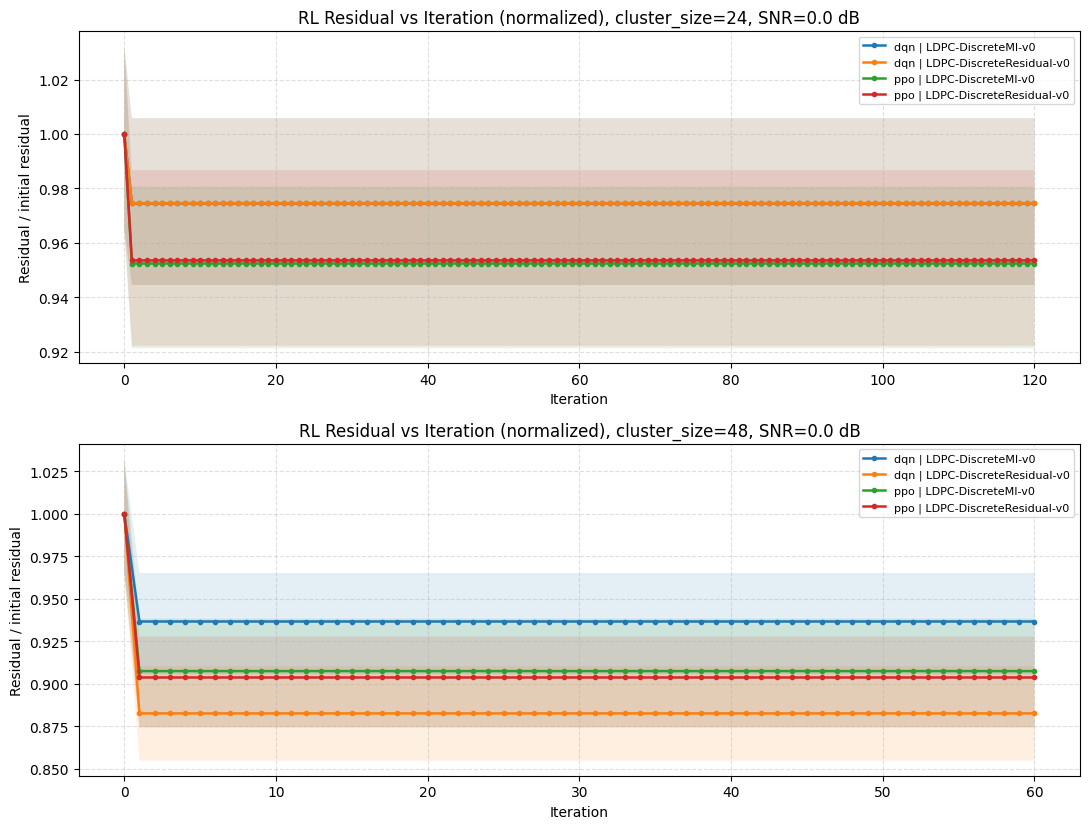

Residual trace summary: /root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/rl/frames_50/residual_traces/residual_trace_summary.csv
Residual trace plot:    /root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/rl/frames_50/residual_traces/rl_residual_vs_iteration.png


,cluster_size,algo,env_id,env_short,model_path,trace_csv,snr_db,episodes,n_iterations,final_over_initial,decrease_fraction
0,24,dqn,gymnasium_env_2/LDPC-DiscreteMI-v0,LDPC-DiscreteMI-v0,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...,0.0,10,121,0.974501,1.0
1,24,dqn,gymnasium_env_2/LDPC-DiscreteResidual-v0,LDPC-DiscreteResidual-v0,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...,0.0,10,121,0.974501,1.0
2,24,ppo,gymnasium_env_2/LDPC-DiscreteMI-v0,LDPC-DiscreteMI-v0,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...,0.0,10,121,0.952385,1.0
3,24,ppo,gymnasium_env_2/LDPC-DiscreteResidual-v0,LDPC-DiscreteResidual-v0,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...,0.0,10,121,0.953511,1.0
4,48,dqn,gymnasium_env_2/LDPC-DiscreteMI-v0,LDPC-DiscreteMI-v0,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...,0.0,10,61,0.936544,1.0
5,48,dqn,gymnasium_env_2/LDPC-DiscreteResidual-v0,LDPC-DiscreteResidual-v0,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...,0.0,10,61,0.882487,1.0
6,48,ppo,gymnasium_env_2/LDPC-DiscreteMI-v0,LDPC-DiscreteMI-v0,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...,0.0,10,61,0.907370,1.0
7,48,ppo,gymnasium_env_2/LDPC-DiscreteResidual-v0,LDPC-DiscreteResidual-v0,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...,0.0,10,61,0.903617,1.0


In [36]:
import gymnasium as gym
from stable_baselines3 import PPO, DQN

# Load train summary if needed
if 'rl_train_df' not in globals() or rl_train_df is None or len(rl_train_df) == 0:
    rl_train_df = pd.read_csv(rl_train_csv_default)

trace_snr_db = 0.0
trace_episodes = 10
algo_loader = {'ppo': PPO, 'dqn': DQN}

residual_dir = Path(ROOT) / 'RL' / 'results' / 'newmatrix' / 'rl' / f'frames_{RL_EVAL_FRAMES}' / 'residual_traces'
residual_dir.mkdir(parents=True, exist_ok=True)

def make_trace_env(env_id, cluster_size, snr_db):
    num_clusters = m // int(cluster_size)
    env_max_iterations = MAX_SWEEPS * num_clusters
    return gym.make(
        env_id,
        H_path=H_PATH,
        num_clusters=num_clusters,
        max_iterations=env_max_iterations,
        snr_db=snr_db,
        codeword_mode='all_zero',
        bins=8,
    )

def collect_mean_residual_trace(model, env_id, cluster_size, snr_db, n_episodes, seed):
    env = make_trace_env(env_id, cluster_size=cluster_size, snr_db=snr_db)
    episode_traces = []

    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)

        initial_residual = float(np.sum(np.abs(env.unwrapped.decoder.get_residuals())))
        trace = [initial_residual]

        for _ in range(env.unwrapped.max_iterations):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            residual_now = float(np.sum(np.abs(env.unwrapped.decoder.get_residuals())))
            trace.append(residual_now)
            if terminated or truncated:
                break

        episode_traces.append(trace)

    env.close()

    max_len = max(len(t) for t in episode_traces)
    arr = np.zeros((len(episode_traces), max_len), dtype=np.float64)
    for i, t in enumerate(episode_traces):
        arr[i, :len(t)] = t
        arr[i, len(t):] = t[-1]

    mean_trace = arr.mean(axis=0)
    p25_trace = np.percentile(arr, 25, axis=0)
    p75_trace = np.percentile(arr, 75, axis=0)

    denom = max(mean_trace[0], 1e-12)
    mean_norm = mean_trace / denom
    p25_norm = p25_trace / denom
    p75_norm = p75_trace / denom

    return {
        'mean_trace': mean_trace,
        'p25_trace': p25_trace,
        'p75_trace': p75_trace,
        'mean_norm': mean_norm,
        'p25_norm': p25_norm,
        'p75_norm': p75_norm,
        'n_iterations': len(mean_trace),
        'final_over_initial': float(mean_norm[-1]),
        'decrease_fraction': float(np.mean(np.diff(mean_trace) <= 0)) if len(mean_trace) > 1 else 1.0,
    }

trace_records = []
plotted = []
missing_models = []

for _, row in rl_train_df.iterrows():
    algo = row['algo']
    env_id = row['env_id']
    cluster_size = int(row['cluster_size'])
    model_path = Path(row['model_path'])

    if not model_path.exists():
        missing_models.append(str(model_path))
        continue

    model_cls = algo_loader.get(algo)
    if model_cls is None:
        continue

    model = model_cls.load(str(model_path), device='cpu')
    trace = collect_mean_residual_trace(
        model,
        env_id=env_id,
        cluster_size=cluster_size,
        snr_db=trace_snr_db,
        n_episodes=trace_episodes,
        seed=SEED,
    )

    env_short = env_id.split('/')[-1]
    combo_label = f"{algo} | {env_short}"

    trace_df = pd.DataFrame({
        'iteration': np.arange(trace['n_iterations']),
        'mean_residual': trace['mean_trace'],
        'p25_residual': trace['p25_trace'],
        'p75_residual': trace['p75_trace'],
        'mean_residual_norm': trace['mean_norm'],
        'p25_residual_norm': trace['p25_norm'],
        'p75_residual_norm': trace['p75_norm'],
    })

    out_dir = residual_dir / f'cluster_{cluster_size}' / algo
    out_dir.mkdir(parents=True, exist_ok=True)
    out_csv = out_dir / f"{env_short}_residual_trace.csv"
    trace_df.to_csv(out_csv, index=False)

    trace_records.append({
        'cluster_size': cluster_size,
        'algo': algo,
        'env_id': env_id,
        'env_short': env_short,
        'model_path': str(model_path),
        'trace_csv': str(out_csv),
        'snr_db': trace_snr_db,
        'episodes': trace_episodes,
        'n_iterations': trace['n_iterations'],
        'final_over_initial': trace['final_over_initial'],
        'decrease_fraction': trace['decrease_fraction'],
    })

    plotted.append({
        'cluster_size': cluster_size,
        'label': combo_label,
        'x': np.arange(trace['n_iterations']),
        'y': trace['mean_norm'],
        'y_lo': trace['p25_norm'],
        'y_hi': trace['p75_norm'],
    })

residual_summary_df = pd.DataFrame(trace_records)
summary_csv = residual_dir / 'residual_trace_summary.csv'
residual_summary_df.to_csv(summary_csv, index=False)

cluster_sizes_trace = sorted({p['cluster_size'] for p in plotted})
fig, axes = plt.subplots(len(cluster_sizes_trace), 1, figsize=(11, 4.2 * max(1, len(cluster_sizes_trace))), sharex=False)
if len(cluster_sizes_trace) == 1:
    axes = [axes]

for idx, cluster_size in enumerate(cluster_sizes_trace):
    ax = axes[idx]
    sub = [p for p in plotted if p['cluster_size'] == cluster_size]
    for p in sub:
        ax.plot(p['x'], p['y'], marker='o', markersize=3, lw=1.8, label=p['label'])
        ax.fill_between(p['x'], p['y_lo'], p['y_hi'], alpha=0.12)
    ax.set_title(f'RL Residual vs Iteration (normalized), cluster_size={cluster_size}, SNR={trace_snr_db} dB')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Residual / initial residual')
    ax.grid(True, ls='--', alpha=0.4)
    ax.legend(fontsize=8)

plt.tight_layout()
residual_plot_path = residual_dir / 'rl_residual_vs_iteration.png'
plt.savefig(residual_plot_path, dpi=220, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f'Residual trace summary: {summary_csv}')
print(f'Residual trace plot:    {residual_plot_path}')
if len(missing_models) > 0:
    print(f'Missing models skipped: {len(missing_models)}')

residual_summary_df.sort_values(['cluster_size', 'algo', 'env_short'])

## Raw Max Residual per Cluster (No Normalization, No Averaging)
For each algorithm/method, this section plots max residual of every cluster in one graph using a single run.

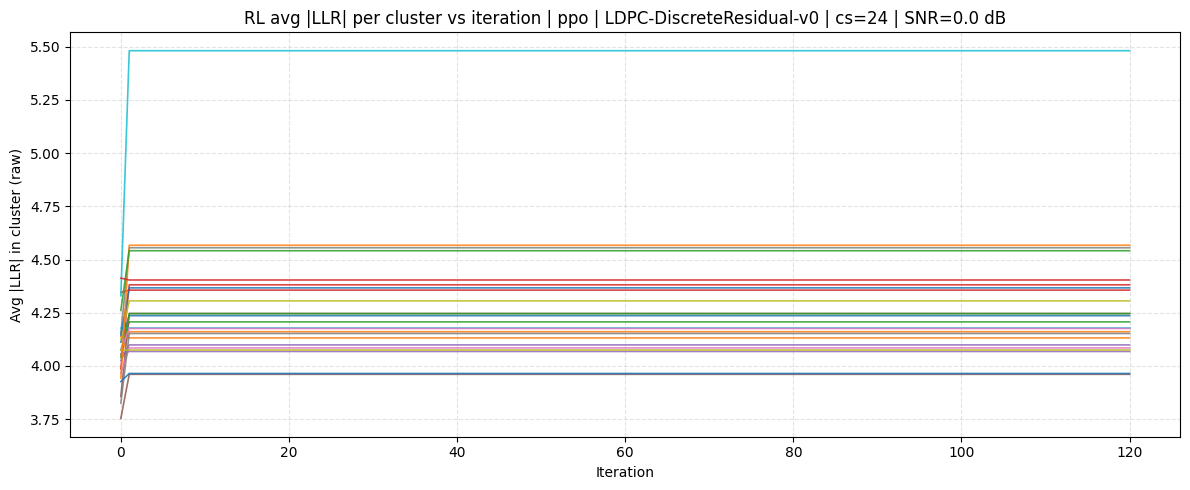

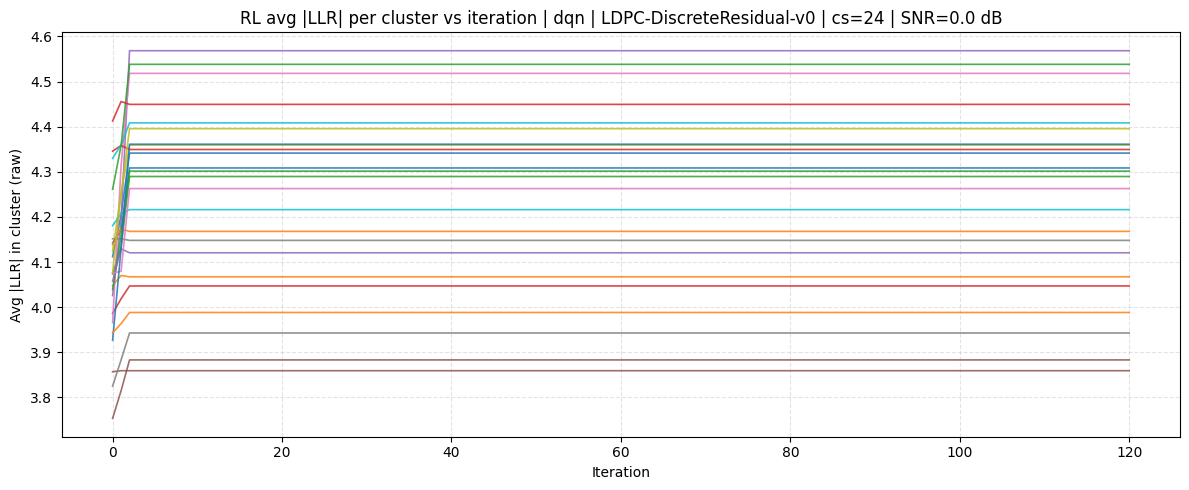

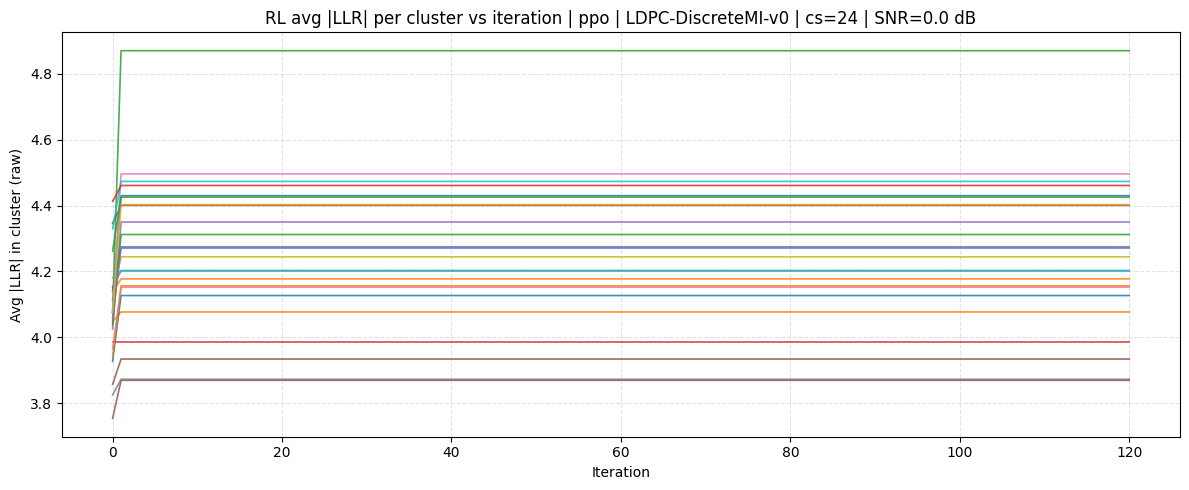

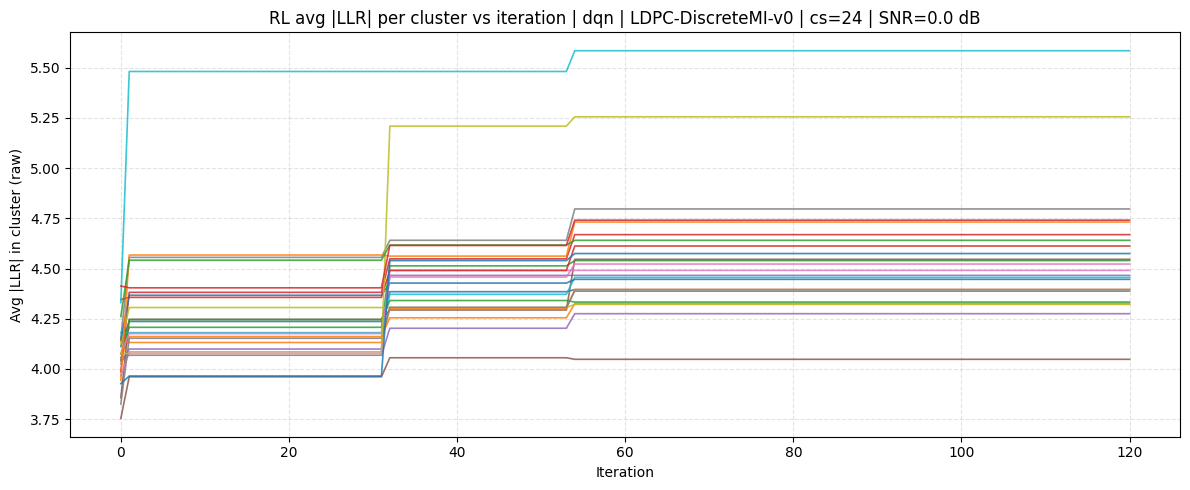

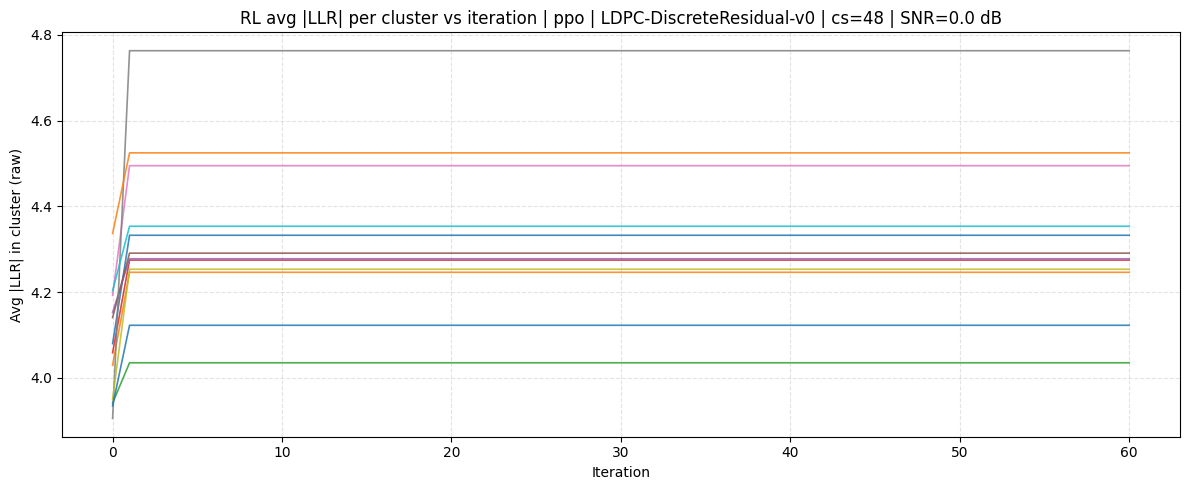

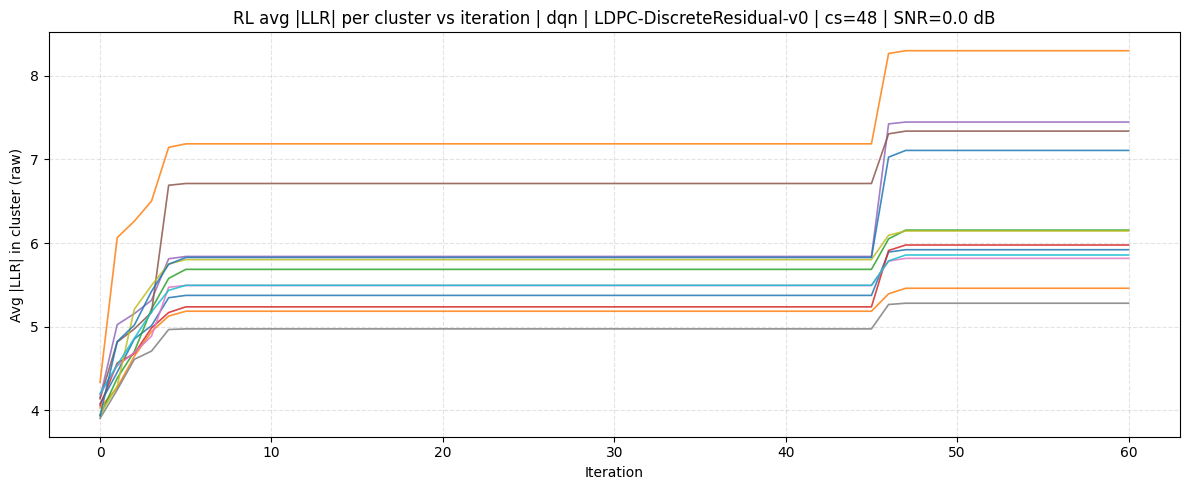

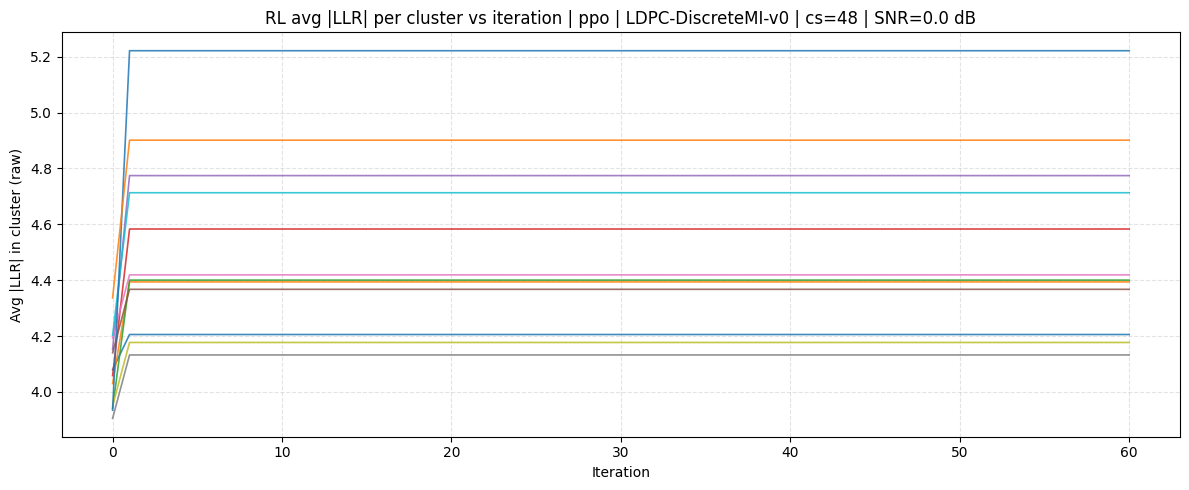

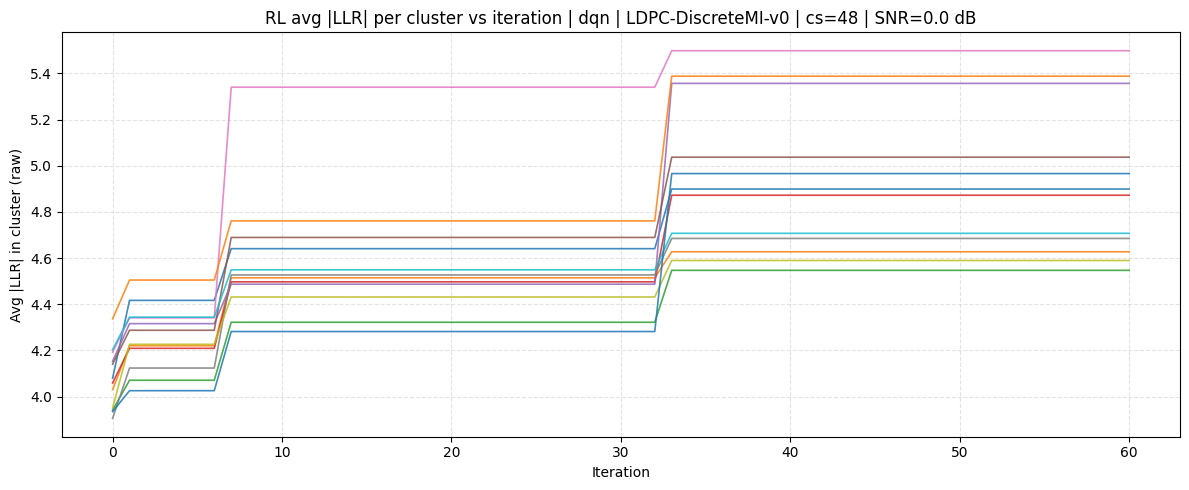

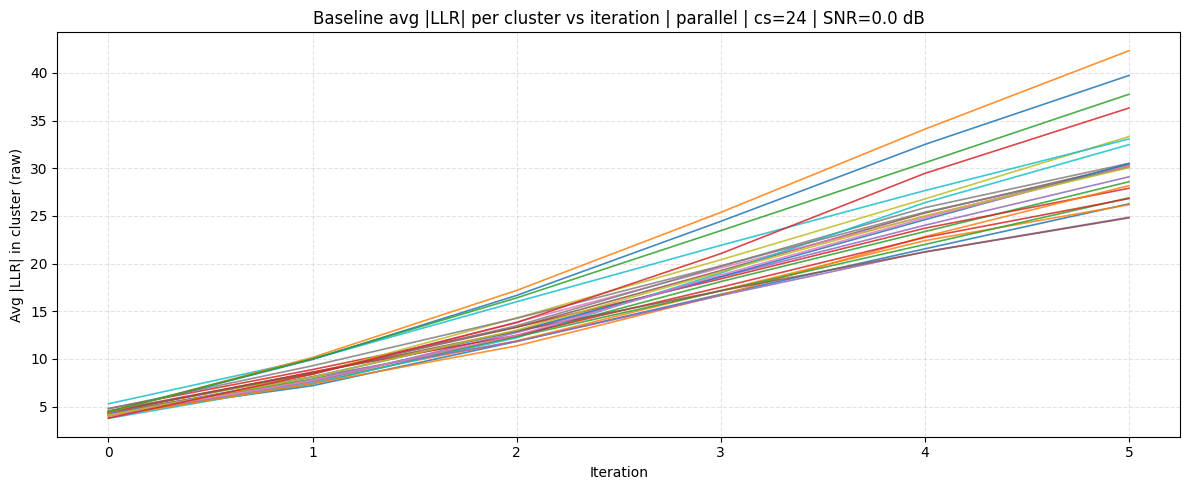

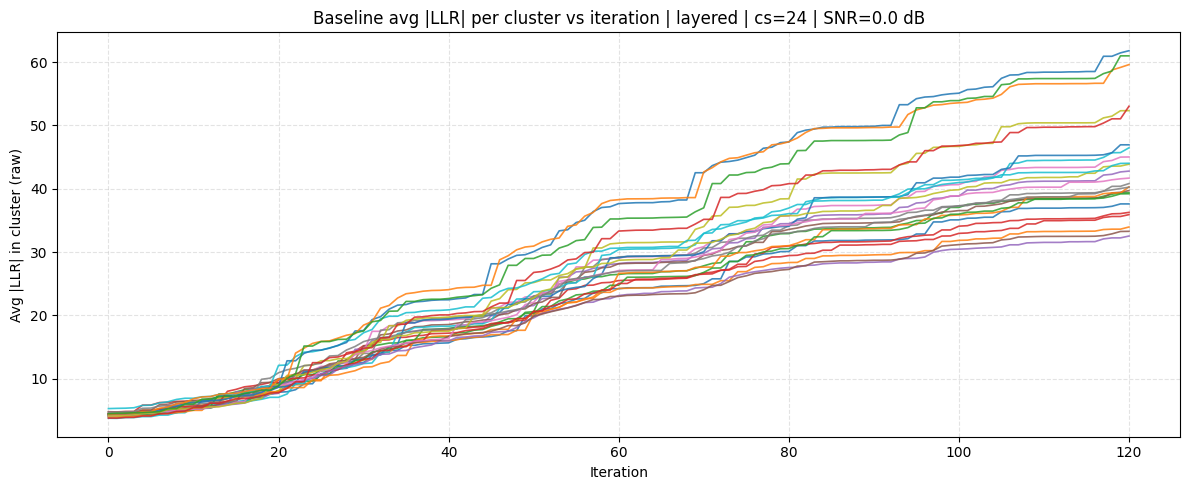

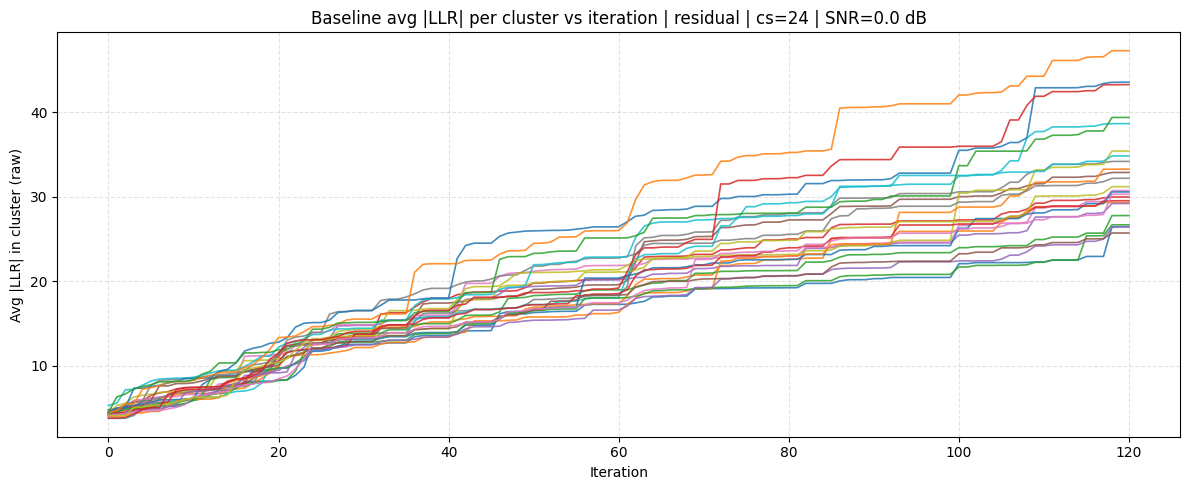

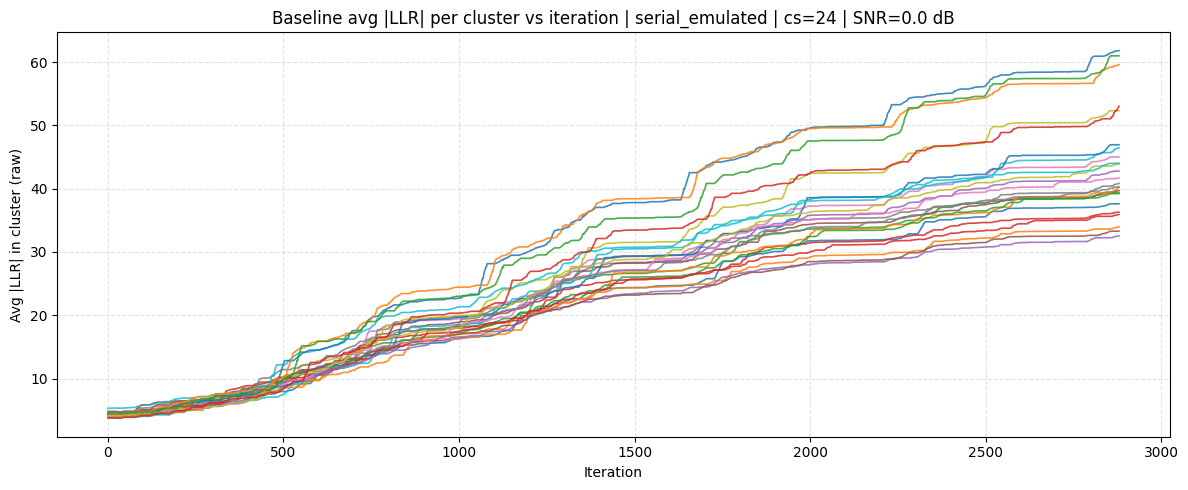

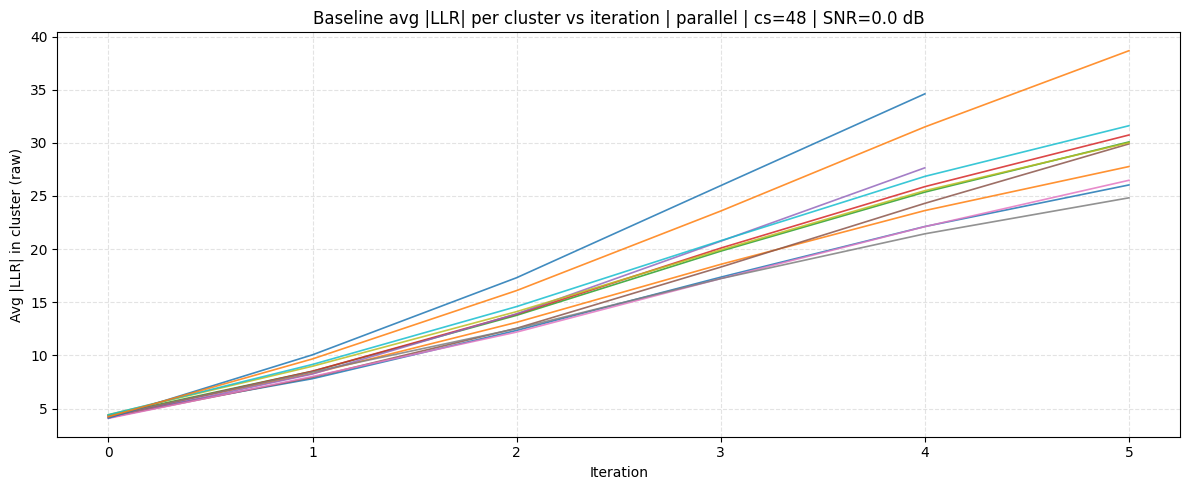

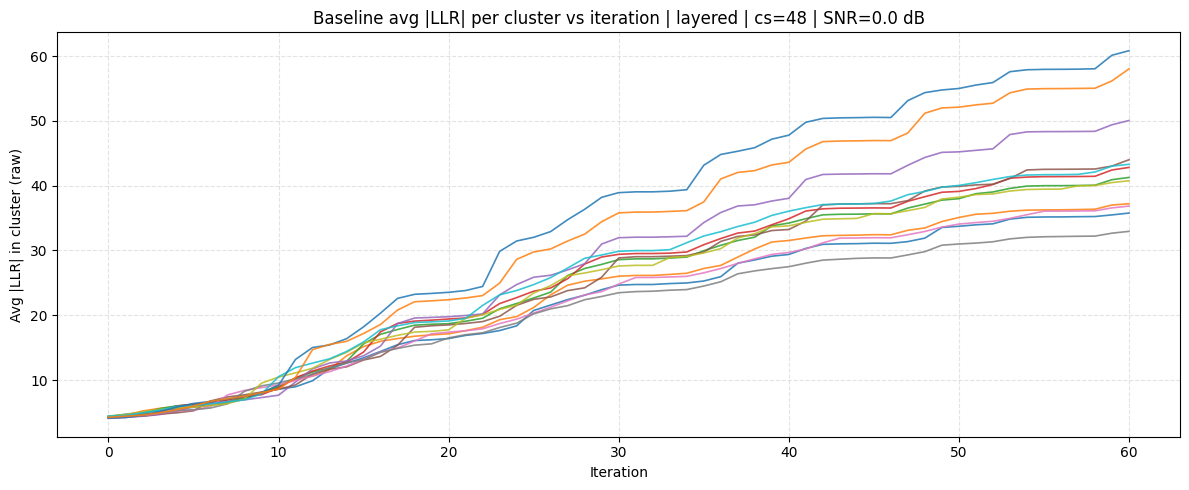

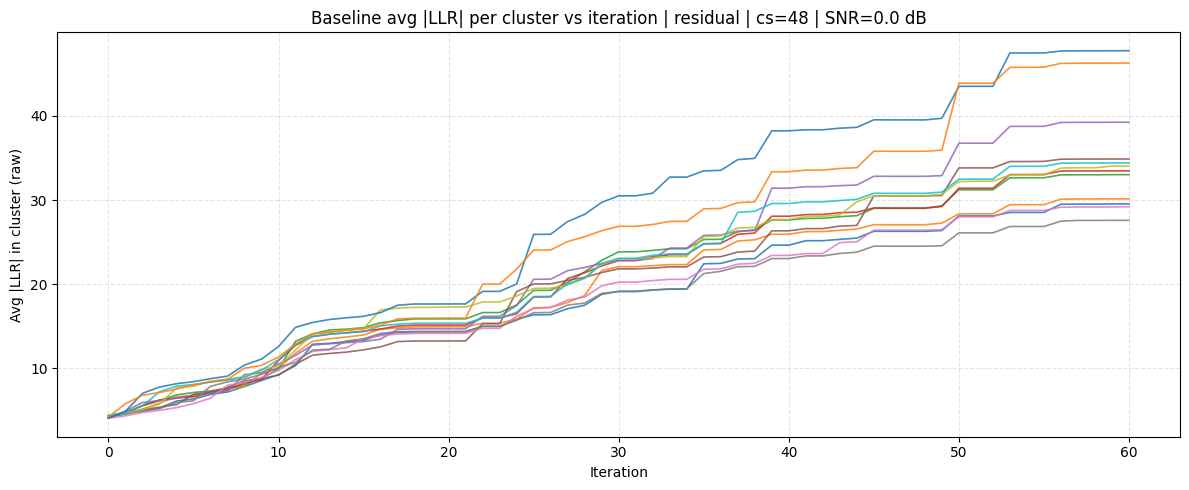

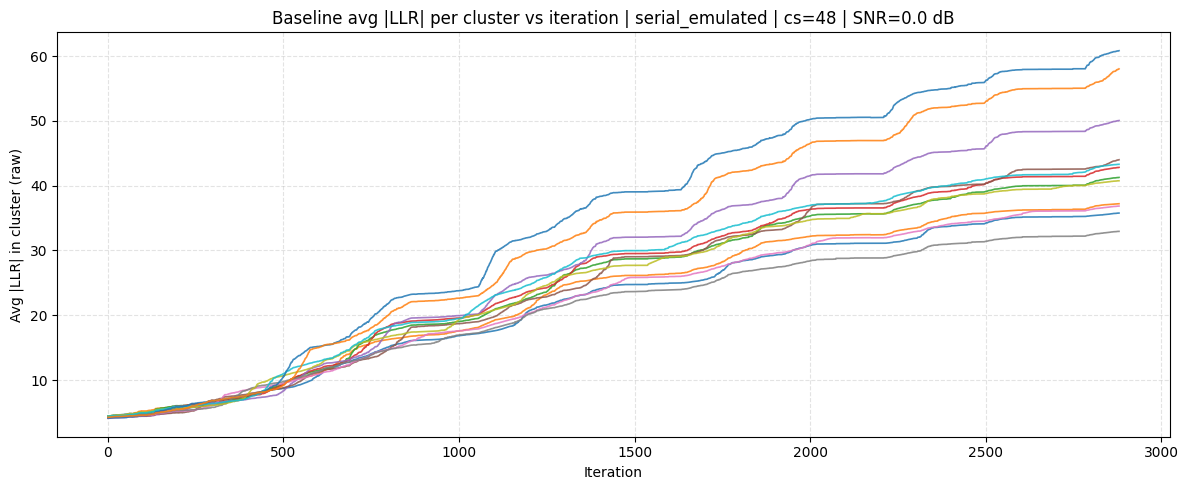

Raw cluster-avg |LLR| trace summary: /root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/llr_abs_cluster_avg_raw/raw_cluster_avg_llr_trace_summary.csv
RL policy triviality summary:       /root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/llr_abs_cluster_avg_raw/rl_policy_triviality_summary.csv
Raw avg |LLR| trace root:           /root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/llr_abs_cluster_avg_raw


,cluster_size,algo,env_short,episodes_checked,unique_actions,dominant_action,dominant_action_fraction,normalized_entropy,is_trivial_policy
3,24,dqn,LDPC-DiscreteMI-v0,20,10,5,0.457917,0.501877,False
1,24,dqn,LDPC-DiscreteResidual-v0,20,11,4,0.517500,0.324483,False
2,24,ppo,LDPC-DiscreteMI-v0,20,1,2,1.000000,-0.000000,True
0,24,ppo,LDPC-DiscreteResidual-v0,20,1,19,1.000000,-0.000000,True
7,48,dqn,LDPC-DiscreteMI-v0,20,6,4,0.627500,0.403886,False
5,48,dqn,LDPC-DiscreteResidual-v0,20,9,2,0.754167,0.363051,False
6,48,ppo,LDPC-DiscreteMI-v0,20,1,10,1.000000,-0.000000,True
4,48,ppo,LDPC-DiscreteResidual-v0,20,1,7,1.000000,-0.000000,True


In [43]:
# Raw trace settings for avg(|LLR|)
raw_trace_snr_db = 0.0
raw_trace_seed = SEED + 123
policy_check_episodes = 20

llr_avg_trace_root = Path(ROOT) / 'RL' / 'results' / 'newmatrix' / 'llr_abs_cluster_avg_raw'
llr_avg_trace_root.mkdir(parents=True, exist_ok=True)

def build_cluster_var_index_map(cluster_checks):
    var_map = []
    for check_cluster in cluster_checks:
        check_cluster = np.asarray(check_cluster, dtype=np.int32)
        sub_h = H[check_cluster]
        var_idx = np.unique(sub_h.indices).astype(np.int32)
        var_map.append(var_idx)
    return var_map

def cluster_avg_abs_llr_vector(llr_vec, cluster_var_idx_map):
    vals = np.zeros(len(cluster_var_idx_map), dtype=np.float64)
    for i, var_idx in enumerate(cluster_var_idx_map):
        if len(var_idx) == 0:
            vals[i] = 0.0
        else:
            vals[i] = float(np.mean(np.abs(llr_vec[var_idx])))
    return vals

def add_cluster_rows(rows, source, mode_label, cluster_size, iteration, cluster_vals, snr_db):
    for cluster_id, value in enumerate(cluster_vals):
        rows.append({
            'source': source,
            'mode': mode_label,
            'cluster_size': int(cluster_size),
            'iteration': int(iteration),
            'cluster_id': int(cluster_id),
            'avg_abs_llr': float(value),
            'snr_db': float(snr_db),
        })

def save_cluster_plot(df_trace, title, out_path):
    fig, ax = plt.subplots(figsize=(12, 5))
    for cluster_id, df_c in df_trace.groupby('cluster_id'):
        df_c = df_c.sort_values('iteration')
        ax.plot(df_c['iteration'], df_c['avg_abs_llr'], lw=1.2, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Avg |LLR| in cluster (raw)')
    ax.grid(True, ls='--', alpha=0.35)
    plt.tight_layout()
    plt.savefig(out_path, dpi=220, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def collect_rl_cluster_avg_llr_trace(model, env_id, cluster_size, snr_db, seed):
    env = make_trace_env(env_id, cluster_size=cluster_size, snr_db=snr_db)
    obs, _ = env.reset(seed=seed)

    check_clusters = [np.asarray(c, dtype=np.int32) for c in env.unwrapped.schedule]
    var_map = build_cluster_var_index_map(check_clusters)
    rows = []

    llr_vec = np.asarray(env.unwrapped.current_llr, dtype=np.float64)
    vals = cluster_avg_abs_llr_vector(llr_vec, var_map)
    add_cluster_rows(rows, 'rl', f"{model.__class__.__name__.lower()} | {env_id.split('/')[-1]}", cluster_size, 0, vals, snr_db)

    for t in range(1, env.unwrapped.max_iterations + 1):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        llr_vec = np.asarray(env.unwrapped.current_llr, dtype=np.float64)
        vals = cluster_avg_abs_llr_vector(llr_vec, var_map)
        add_cluster_rows(rows, 'rl', f"{model.__class__.__name__.lower()} | {env_id.split('/')[-1]}", cluster_size, t, vals, snr_db)
        if terminated or truncated:
            break

    env.close()
    return pd.DataFrame(rows)

def collect_baseline_cluster_avg_llr_trace(method_name, cluster_size, llr, max_sweeps):
    grouped_clusters, num_clusters = make_layered_clusters(cluster_size)
    var_map = build_cluster_var_index_map(grouped_clusters)
    rows = []

    if method_name == 'parallel':
        d0 = BpDecoder(H, max_iter=1)
        d0.reset()
        d0.initialise_log_domain_bp(llr)
        llr0 = np.asarray(d0.log_prob_ratios, dtype=np.float64)
        vals0 = cluster_avg_abs_llr_vector(llr0, var_map)
        add_cluster_rows(rows, 'baseline', method_name, cluster_size, 0, vals0, raw_trace_snr_db)

        for k in range(1, max_sweeps + 1):
            dk = BpDecoder(H, max_iter=k)
            _ = dk.decode(llr)
            llr_k = np.asarray(dk.log_prob_ratios, dtype=np.float64)
            vals = cluster_avg_abs_llr_vector(llr_k, var_map)
            add_cluster_rows(rows, 'baseline', method_name, cluster_size, k, vals, raw_trace_snr_db)

        return pd.DataFrame(rows)

    d = BpDecoder(H, max_iter=max_sweeps)
    d.reset()
    d.initialise_log_domain_bp(llr)
    llr0 = np.asarray(d.log_prob_ratios, dtype=np.float64)
    vals0 = cluster_avg_abs_llr_vector(llr0, var_map)
    add_cluster_rows(rows, 'baseline', method_name, cluster_size, 0, vals0, raw_trace_snr_db)

    if method_name == 'layered':
        total_actions = max_sweeps * num_clusters
        for t in range(1, total_actions + 1):
            chosen = grouped_clusters[(t - 1) % num_clusters]
            llr_now = np.asarray(d.decode_cluster(chosen), dtype=np.float64)
            vals = cluster_avg_abs_llr_vector(llr_now, var_map)
            add_cluster_rows(rows, 'baseline', method_name, cluster_size, t, vals, raw_trace_snr_db)

    elif method_name == 'residual':
        total_actions = max_sweeps * num_clusters
        for t in range(1, total_actions + 1):
            current_res = np.asarray(d.get_residuals())
            idx, chosen = pick_max_avg_residual_cluster(current_res, grouped_clusters)
            if chosen is None:
                break
            llr_now = np.asarray(d.decode_cluster(chosen), dtype=np.float64)
            vals = cluster_avg_abs_llr_vector(llr_now, var_map)
            add_cluster_rows(rows, 'baseline', method_name, cluster_size, t, vals, raw_trace_snr_db)

    elif method_name == 'serial_emulated':
        serial = [np.array([i], dtype=np.int32) for i in range(m)]
        total_actions = max_sweeps * len(serial)
        for t in range(1, total_actions + 1):
            chosen = serial[(t - 1) % len(serial)]
            llr_now = np.asarray(d.decode_cluster(chosen), dtype=np.float64)
            vals = cluster_avg_abs_llr_vector(llr_now, var_map)
            add_cluster_rows(rows, 'baseline', method_name, cluster_size, t, vals, raw_trace_snr_db)

    else:
        raise ValueError(f'Unknown baseline method: {method_name}')

    return pd.DataFrame(rows)

def check_policy_triviality(model, env_id, cluster_size, snr_db, episodes, seed):
    env = make_trace_env(env_id, cluster_size=cluster_size, snr_db=snr_db)
    n_actions = env.action_space.n
    all_actions = []
    episode_lengths = []

    for ep in range(episodes):
        obs, _ = env.reset(seed=seed + ep)
        ep_actions = []

        for _ in range(env.unwrapped.max_iterations):
            action, _ = model.predict(obs, deterministic=True)
            action = int(action)
            ep_actions.append(action)
            obs, reward, terminated, truncated, info = env.step(action)
            if terminated or truncated:
                break

        all_actions.extend(ep_actions)
        episode_lengths.append(len(ep_actions))

    env.close()

    if len(all_actions) == 0:
        return {
            'n_actions': n_actions,
            'total_steps': 0,
            'unique_actions': 0,
            'dominant_action': -1,
            'dominant_action_fraction': np.nan,
            'action_entropy': np.nan,
            'normalized_entropy': np.nan,
            'is_trivial_policy': True,
            'mean_episode_steps': 0.0,
        }

    counts = np.bincount(np.array(all_actions, dtype=np.int32), minlength=n_actions)
    probs = counts / counts.sum()
    non_zero = probs[probs > 0]
    entropy = float(-np.sum(non_zero * np.log(non_zero)))
    norm_entropy = float(entropy / np.log(n_actions)) if n_actions > 1 else 0.0

    dominant_action = int(np.argmax(counts))
    dominant_fraction = float(counts[dominant_action] / counts.sum())
    unique_actions = int(np.count_nonzero(counts))

    is_trivial = (dominant_fraction >= 0.95) or (unique_actions <= 1) or (norm_entropy <= 0.1)

    return {
        'n_actions': int(n_actions),
        'total_steps': int(counts.sum()),
        'unique_actions': unique_actions,
        'dominant_action': dominant_action,
        'dominant_action_fraction': dominant_fraction,
        'action_entropy': entropy,
        'normalized_entropy': norm_entropy,
        'is_trivial_policy': bool(is_trivial),
        'mean_episode_steps': float(np.mean(episode_lengths)),
    }

# ----- RL traces from saved models first -----
if 'rl_train_df' not in globals() or rl_train_df is None or len(rl_train_df) == 0:
    rl_train_df = pd.read_csv(rl_train_csv_default)

algo_loader = {'ppo': PPO, 'dqn': DQN}
rl_llr_summary_rows = []
policy_rows = []

for _, row in rl_train_df.iterrows():
    cluster_size = int(row['cluster_size'])
    algo = row['algo']
    env_id = row['env_id']
    env_short = env_id.split('/')[-1]
    model_path = Path(row['model_path'])

    if not model_path.exists():
        continue

    model_cls = algo_loader.get(algo)
    if model_cls is None:
        continue

    model = model_cls.load(str(model_path), device='cpu')

    df_trace = collect_rl_cluster_avg_llr_trace(
        model=model,
        env_id=env_id,
        cluster_size=cluster_size,
        snr_db=raw_trace_snr_db,
        seed=raw_trace_seed,
    )

    rl_out_dir = llr_avg_trace_root / 'rl' / f'cluster_{cluster_size}' / algo
    rl_out_dir.mkdir(parents=True, exist_ok=True)
    trace_csv = rl_out_dir / f'{env_short}_cluster_avg_llr_trace.csv'
    trace_png = rl_out_dir / f'{env_short}_cluster_avg_llr_trace.png'
    df_trace.to_csv(trace_csv, index=False)

    save_cluster_plot(
        df_trace,
        title=f'RL avg |LLR| per cluster vs iteration | {algo} | {env_short} | cs={cluster_size} | SNR={raw_trace_snr_db} dB',
        out_path=trace_png,
    )

    first_iter = df_trace[df_trace['iteration'] == 0]['avg_abs_llr'].sum()
    last_iter = df_trace[df_trace['iteration'] == df_trace['iteration'].max()]['avg_abs_llr'].sum()
    rl_llr_summary_rows.append({
        'source': 'rl',
        'mode': f'{algo} | {env_short}',
        'cluster_size': cluster_size,
        'snr_db': raw_trace_snr_db,
        'iterations_recorded': int(df_trace['iteration'].max()),
        'sum_cluster_avg_abs_llr_iter0': float(first_iter),
        'sum_cluster_avg_abs_llr_last': float(last_iter),
        'trace_csv': str(trace_csv),
        'trace_plot': str(trace_png),
    })

    pdiag = check_policy_triviality(
        model=model,
        env_id=env_id,
        cluster_size=cluster_size,
        snr_db=raw_trace_snr_db,
        episodes=policy_check_episodes,
        seed=raw_trace_seed + 1000,
    )
    policy_rows.append({
        'cluster_size': cluster_size,
        'algo': algo,
        'env_id': env_id,
        'env_short': env_short,
        'model_path': str(model_path),
        'snr_db': raw_trace_snr_db,
        'episodes_checked': policy_check_episodes,
        **pdiag,
    })

# ----- Baseline traces -----
baseline_methods_trace = ['parallel', 'layered', 'residual', 'serial_emulated']
baseline_llr_summary_rows = []

for cluster_size in CLUSTER_SIZES:
    np.random.seed(raw_trace_seed + cluster_size)
    llr = make_channel_llr_zero_codeword(n_frames=1, n=n_code, snr_db=raw_trace_snr_db)[0]

    for method in baseline_methods_trace:
        df_trace = collect_baseline_cluster_avg_llr_trace(
            method_name=method,
            cluster_size=cluster_size,
            llr=llr,
            max_sweeps=MAX_SWEEPS,
        )

        b_out_dir = llr_avg_trace_root / 'baseline' / f'cluster_{cluster_size}'
        b_out_dir.mkdir(parents=True, exist_ok=True)
        trace_csv = b_out_dir / f'{method}_cluster_avg_llr_trace.csv'
        trace_png = b_out_dir / f'{method}_cluster_avg_llr_trace.png'
        df_trace.to_csv(trace_csv, index=False)

        save_cluster_plot(
            df_trace,
            title=f'Baseline avg |LLR| per cluster vs iteration | {method} | cs={cluster_size} | SNR={raw_trace_snr_db} dB',
            out_path=trace_png,
        )

        first_iter = df_trace[df_trace['iteration'] == 0]['avg_abs_llr'].sum()
        last_iter = df_trace[df_trace['iteration'] == df_trace['iteration'].max()]['avg_abs_llr'].sum()
        baseline_llr_summary_rows.append({
            'source': 'baseline',
            'mode': method,
            'cluster_size': cluster_size,
            'snr_db': raw_trace_snr_db,
            'iterations_recorded': int(df_trace['iteration'].max()),
            'sum_cluster_avg_abs_llr_iter0': float(first_iter),
            'sum_cluster_avg_abs_llr_last': float(last_iter),
            'trace_csv': str(trace_csv),
            'trace_plot': str(trace_png),
        })

llr_avg_summary_df = pd.concat([
    pd.DataFrame(rl_llr_summary_rows),
    pd.DataFrame(baseline_llr_summary_rows),
], ignore_index=True)

llr_avg_summary_csv = llr_avg_trace_root / 'raw_cluster_avg_llr_trace_summary.csv'
llr_avg_summary_df.to_csv(llr_avg_summary_csv, index=False)

policy_df = pd.DataFrame(policy_rows)
policy_csv = llr_avg_trace_root / 'rl_policy_triviality_summary.csv'
policy_df.to_csv(policy_csv, index=False)

print(f'Raw cluster-avg |LLR| trace summary: {llr_avg_summary_csv}')
print(f'RL policy triviality summary:       {policy_csv}')
print(f'Raw avg |LLR| trace root:           {llr_avg_trace_root}')

display_cols = [
    'cluster_size', 'algo', 'env_short', 'episodes_checked', 'unique_actions',
    'dominant_action', 'dominant_action_fraction', 'normalized_entropy', 'is_trivial_policy'
 ]
policy_df.sort_values(['cluster_size', 'algo', 'env_short'])[display_cols]

## Continuous RL Training (Resume + Checkpoints + Live Plots)
This section supports resumable training: rerun this cell any time to continue from the latest saved checkpoint.

- Saves a checkpoint model every `2000` training steps
- Evaluates each checkpoint and updates progress plots after each checkpoint
- Keeps all checkpoints on disk so you can inspect model evolution
- Produces a global plot comparing RL configs across training steps

In [53]:
import re
import time
from pathlib import Path
import gymnasium as gym

CONT_TARGET_TOTAL_STEPS = 100000
CONT_CHECKPOINT_EVERY = 2000
CONT_IMAGE_UPDATE_EVERY = 5000
CONT_STEP_GAP = 10000
CONT_EVAL_SNR_LIST = [0.0]
CONT_EVAL_FRAMES = 50
CONT_COMPARE_EVAL_FRAMES = 50
CONT_REFERENCE_SNR = 0.0
CONT_SEED_OFFSET = 20000
CONT_MAX_NEW_CHECKPOINTS_PER_CONFIG_PER_RUN = 1
CONT_RUN_TRAINING = True

continuous_root = Path(ROOT) / 'RL' / 'results' / 'newmatrix' / 'rl_continuous' / f'frames_{CONT_EVAL_FRAMES}'
continuous_root.mkdir(parents=True, exist_ok=True)
continuous_plot_dir = continuous_root / 'plot_images'
continuous_plot_dir.mkdir(parents=True, exist_ok=True)

latest_eval_csv = continuous_root / 'latest_rl_eval_all_snr.csv'
continuous_summary_csv = continuous_root / 'continuous_train_summary.csv'
continuous_eval_all_csv = continuous_root / 'continuous_eval_all.csv'

def make_cont_vec_env(env_id, cluster_size):
    def _builder():
        return make_ldpc_env(env_id, cluster_size=cluster_size, snr_db=0.0)
    return DummyVecEnv([_builder])

def build_model_for_continuous(algo_name, vec_env, seed):
    if algo_name == 'ppo':
        return PPO(
            'MlpPolicy',
            vec_env,
            verbose=0,
            seed=seed,
            n_steps=256,
            batch_size=64,
            device='cpu',
        )
    if algo_name == 'dqn':
        return DQN(
            'MlpPolicy',
            vec_env,
            verbose=0,
            seed=seed,
            learning_starts=100,
            buffer_size=5000,
            batch_size=64,
            train_freq=4,
            gradient_steps=1,
            exploration_fraction=0.3,
            device='cpu',
        )
    raise ValueError(f'Unsupported algo: {algo_name}')

def list_checkpoints(ckpt_dir):
    ckpts = []
    for p in ckpt_dir.glob('model_step_*.zip'):
        mobj = re.match(r'model_step_(\d+)\.zip$', p.name)
        if mobj:
            ckpts.append((int(mobj.group(1)), p))
    ckpts.sort(key=lambda x: x[0])
    return ckpts

def load_baseline_metrics_df():
    baseline_csv = Path(ROOT) / 'RL' / 'results' / 'newmatrix' / 'baselines' / f'frames_{N_FRAMES}' / 'baseline_all.csv'
    if baseline_csv.exists():
        return pd.read_csv(baseline_csv)
    if 'results_df' in globals() and results_df is not None and len(results_df) > 0:
        return results_df.copy()
    return pd.DataFrame()

def gather_checkpoint_eval_from_disk(root_dir):
    frames = []
    for cluster_size in CLUSTER_SIZES:
        for algo in RL_ALGOS:
            for env_id in RL_ENV_IDS:
                env_short = env_id.split('/')[-1]
                eval_csv = root_dir / f'cluster_{cluster_size}' / algo / env_short / 'checkpoint_eval.csv'
                if eval_csv.exists():
                    df = pd.read_csv(eval_csv)
                    if len(df) > 0:
                        frames.append(df)
    if len(frames) == 0:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

def plot_global_progress(df_checkpoint, out_dir, reference_snr):
    if df_checkpoint.empty:
        return None
    snr_tag = str(reference_snr).replace('.', 'p')
    ref_df = df_checkpoint[np.isclose(df_checkpoint['snr_db'], reference_snr)].copy()
    if ref_df.empty:
        return None

    ref_df['env_short'] = ref_df['env_id'].str.split('/').str[-1]
    ref_df['combo'] = (
        'cs=' + ref_df['cluster_size'].astype(int).astype(str)
        + ' | ' + ref_df['algo'] + ' | ' + ref_df['env_short']
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    for combo, d in ref_df.groupby('combo'):
        d = d.sort_values('train_steps')
        axes[0].semilogy(d['train_steps'], d['ber'], marker='o', lw=1.6, label=combo)
        axes[1].plot(d['train_steps'], d['fer'], marker='o', lw=1.6, label=combo)

    axes[0].set_title(f'Global BER vs steps @ SNR={reference_snr:g} dB')
    axes[0].set_xlabel('Training steps')
    axes[0].set_ylabel('BER')
    axes[0].grid(True, which='both', ls='--', alpha=0.35)
    axes[0].legend(fontsize=7, ncol=2)

    axes[1].set_title(f'Global FER vs steps @ SNR={reference_snr:g} dB')
    axes[1].set_xlabel('Training steps')
    axes[1].set_ylabel('FER')
    axes[1].grid(True, ls='--', alpha=0.35)
    axes[1].legend(fontsize=7, ncol=2)

    plt.tight_layout()
    out_path = out_dir / f'global_progress_snr_{snr_tag}.png'
    plt.savefig(out_path, dpi=220, bbox_inches='tight')
    plt.close(fig)
    return out_path

def plot_step_gap_and_latest(df_checkpoint, out_dir, gap, reference_snr):
    if df_checkpoint.empty:
        return None
    ref_df = df_checkpoint[np.isclose(df_checkpoint['snr_db'], reference_snr)].copy()
    if ref_df.empty:
        return None

    ref_df['env_short'] = ref_df['env_id'].str.split('/').str[-1]
    ref_df['combo'] = (
        'cs=' + ref_df['cluster_size'].astype(int).astype(str)
        + ' | ' + ref_df['algo'] + ' | ' + ref_df['env_short']
    )

    selected_blocks = []
    group_cols = ['cluster_size', 'env_id', 'algo']
    for _, g in ref_df.groupby(group_cols):
        steps = sorted(g['train_steps'].astype(int).unique().tolist())
        if len(steps) == 0:
            continue
        keep_steps = sorted(set([s for s in steps if s % gap == 0] + [steps[-1]]))
        selected_blocks.append(g[g['train_steps'].isin(keep_steps)])

    if len(selected_blocks) == 0:
        return None
    selected_df = pd.concat(selected_blocks, ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    for combo, d in selected_df.groupby('combo'):
        d = d.sort_values('train_steps')
        axes[0].semilogy(d['train_steps'], d['ber'], marker='o', lw=1.6, label=combo)
        axes[1].plot(d['train_steps'], d['fer'], marker='o', lw=1.6, label=combo)

    axes[0].set_title(f'RL BER vs steps (every {gap} + latest) @ SNR={reference_snr:g} dB')
    axes[0].set_xlabel('Training steps')
    axes[0].set_ylabel('BER')
    axes[0].grid(True, which='both', ls='--', alpha=0.35)
    axes[0].legend(fontsize=7, ncol=2)

    axes[1].set_title(f'RL FER vs steps (every {gap} + latest) @ SNR={reference_snr:g} dB')
    axes[1].set_xlabel('Training steps')
    axes[1].set_ylabel('FER')
    axes[1].grid(True, ls='--', alpha=0.35)
    axes[1].legend(fontsize=7, ncol=2)

    plt.tight_layout()
    snr_tag = str(reference_snr).replace('.', 'p')
    out_path = out_dir / f'rl_step_gap_{gap}_and_latest_snr_{snr_tag}.png'
    plt.savefig(out_path, dpi=220, bbox_inches='tight')
    plt.close(fig)
    return out_path

def update_latest_eval_csv(eval_frames):
    if latest_eval_csv.exists():
        latest_df = pd.read_csv(latest_eval_csv)
    else:
        latest_df = pd.DataFrame()

    all_new_rows = []
    for cluster_size in CLUSTER_SIZES:
        for algo in RL_ALGOS:
            for env_id in RL_ENV_IDS:
                env_short = env_id.split('/')[-1]
                ckpt_dir = continuous_root / f'cluster_{cluster_size}' / algo / env_short / 'checkpoints'
                ckpts = list_checkpoints(ckpt_dir)
                if len(ckpts) == 0:
                    continue

                train_steps, latest_ckpt = ckpts[-1]
                has_fresh = False
                if not latest_df.empty:
                    sub = latest_df[
                        (latest_df['cluster_size'] == cluster_size)
                        & (latest_df['algo'] == algo)
                        & (latest_df['env_id'] == env_id)
                        & (latest_df['train_steps'] == train_steps)
                        & (latest_df['eval_frames'] == eval_frames)
                    ]
                    has_fresh = (
                        len(sub) == len(SNR_DB_LIST)
                        and set(np.round(sub['snr_db'].astype(float), 8)) == set(np.round(np.array(SNR_DB_LIST, dtype=float), 8))
                    )
                if has_fresh:
                    continue

                model = ALGO_MAP[algo].load(str(latest_ckpt), device='cpu')
                for snr_db in SNR_DB_LIST:
                    metrics = evaluate_model(
                        model,
                        env_id=env_id,
                        cluster_size=cluster_size,
                        snr_db=snr_db,
                        n_frames=eval_frames,
                        seed=SEED + CONT_SEED_OFFSET + train_steps,
                    )
                    all_new_rows.append({
                        'cluster_size': int(cluster_size),
                        'num_clusters': int(m // cluster_size),
                        'env_id': env_id,
                        'algo': algo,
                        'env_short': env_short,
                        'train_steps': int(train_steps),
                        'checkpoint_model_path': str(latest_ckpt),
                        'snr_db': float(snr_db),
                        **metrics,
                        'eval_frames': int(eval_frames),
                    })

    if len(all_new_rows) > 0:
        new_df = pd.DataFrame(all_new_rows)
        latest_df = pd.concat([latest_df, new_df], ignore_index=True)
        latest_df = latest_df.drop_duplicates(
            subset=['cluster_size', 'env_id', 'algo', 'train_steps', 'snr_db', 'eval_frames'],
            keep='last'
        ).sort_values(['cluster_size', 'env_id', 'algo', 'train_steps', 'snr_db'])
        latest_df.to_csv(latest_eval_csv, index=False)
    elif latest_eval_csv.exists():
        latest_df = pd.read_csv(latest_eval_csv)

    return latest_df

def plot_baseline_vs_latest_rl(baseline_df, latest_df, out_dir):
    if baseline_df.empty or latest_df.empty:
        return None

    latest_df = latest_df.copy()
    latest_df['env_short'] = latest_df['env_id'].str.split('/').str[-1]
    latest_df['combo'] = latest_df['algo'] + ' | ' + latest_df['env_short']

    idx = latest_df.groupby(['cluster_size', 'algo', 'env_id'])['train_steps'].idxmax()
    latest_only = latest_df.loc[idx].copy()

    rows = []
    for _, r in latest_only.iterrows():
        sub = latest_df[
            (latest_df['cluster_size'] == r['cluster_size'])
            & (latest_df['algo'] == r['algo'])
            & (latest_df['env_id'] == r['env_id'])
            & (latest_df['train_steps'] == r['train_steps'])
        ].copy()
        sub['label'] = sub['combo'] + ' | step=' + sub['train_steps'].astype(int).astype(str)
        rows.append(sub)

    if len(rows) == 0:
        return None
    latest_plot_df = pd.concat(rows, ignore_index=True)

    cluster_sizes_cmp = sorted(set(baseline_df['cluster_size']).intersection(set(latest_plot_df['cluster_size'])))
    if len(cluster_sizes_cmp) == 0:
        return None

    baseline_methods = sorted(baseline_df['method'].unique().tolist())

    fig, axes = plt.subplots(len(cluster_sizes_cmp), 2, figsize=(16, 4.8 * len(cluster_sizes_cmp)), sharex=True)
    if len(cluster_sizes_cmp) == 1:
        axes = np.array([axes])

    for row_idx, cluster_size in enumerate(cluster_sizes_cmp):
        df_b = baseline_df[baseline_df['cluster_size'] == cluster_size]
        df_r = latest_plot_df[latest_plot_df['cluster_size'] == cluster_size]

        for method in baseline_methods:
            d = df_b[df_b['method'] == method].sort_values('snr_db')
            axes[row_idx, 0].semilogy(d['snr_db'], d['ber'], marker='o', lw=1.9, label=f'Baseline: {method}')
            axes[row_idx, 1].plot(d['snr_db'], d['fer'], marker='o', lw=1.9, label=f'Baseline: {method}')

        for label, d in df_r.groupby('label'):
            d = d.sort_values('snr_db')
            axes[row_idx, 0].semilogy(d['snr_db'], d['ber'], marker='x', ls='--', lw=1.8, label=f'RL latest: {label}')
            axes[row_idx, 1].plot(d['snr_db'], d['fer'], marker='x', ls='--', lw=1.8, label=f'RL latest: {label}')

        axes[row_idx, 0].set_title(f'Baseline vs latest RL BER (cluster_size={cluster_size})')
        axes[row_idx, 0].set_ylabel('BER')
        axes[row_idx, 0].grid(True, which='both', ls='--', alpha=0.35)
        axes[row_idx, 0].legend(fontsize=7, ncol=2)

        axes[row_idx, 1].set_title(f'Baseline vs latest RL FER (cluster_size={cluster_size})')
        axes[row_idx, 1].set_ylabel('FER')
        axes[row_idx, 1].grid(True, ls='--', alpha=0.35)
        axes[row_idx, 1].legend(fontsize=7, ncol=2)

    for ax in axes[-1]:
        ax.set_xlabel('SNR (dB)')

    plt.tight_layout()
    out_path = out_dir / 'baseline_vs_latest_rl_ber_fer.png'
    plt.savefig(out_path, dpi=220, bbox_inches='tight')
    plt.close(fig)
    return out_path

def refresh_continuous_plot_images(run_latest_eval, eval_frames, reason):
    checkpoint_df = gather_checkpoint_eval_from_disk(continuous_root)
    checkpoint_df.to_csv(continuous_eval_all_csv, index=False)

    global_plot = plot_global_progress(checkpoint_df, continuous_plot_dir, CONT_REFERENCE_SNR)
    step_plot = plot_step_gap_and_latest(checkpoint_df, continuous_plot_dir, CONT_STEP_GAP, CONT_REFERENCE_SNR)

    if run_latest_eval:
        latest_df = update_latest_eval_csv(eval_frames=eval_frames)
    elif latest_eval_csv.exists():
        latest_df = pd.read_csv(latest_eval_csv)
    else:
        latest_df = pd.DataFrame()

    baseline_df = load_baseline_metrics_df()
    baseline_latest_plot = plot_baseline_vs_latest_rl(baseline_df, latest_df, continuous_plot_dir)

    print(f"[plot-refresh:{reason}] checkpoint_eval_all={continuous_eval_all_csv}")
    if global_plot is not None:
        print(f"[plot-refresh:{reason}] global_progress={global_plot}")
    if step_plot is not None:
        print(f"[plot-refresh:{reason}] step_compare={step_plot}")
    if baseline_latest_plot is not None:
        print(f"[plot-refresh:{reason}] baseline_vs_latest={baseline_latest_plot}")

    return {
        'global_progress_plot': str(global_plot) if global_plot is not None else '',
        'step_compare_plot': str(step_plot) if step_plot is not None else '',
        'baseline_vs_latest_plot': str(baseline_latest_plot) if baseline_latest_plot is not None else '',
    }

continuous_summary_rows = []

if CONT_RUN_TRAINING:
    for cluster_size in CLUSTER_SIZES:
        for env_id in RL_ENV_IDS:
            env_short = env_id.split('/')[-1]
            for algo in RL_ALGOS:
                cfg_dir = continuous_root / f'cluster_{cluster_size}' / algo / env_short
                ckpt_dir = cfg_dir / 'checkpoints'
                cfg_dir.mkdir(parents=True, exist_ok=True)
                ckpt_dir.mkdir(parents=True, exist_ok=True)

                eval_csv = cfg_dir / 'checkpoint_eval.csv'
                eval_df = pd.read_csv(eval_csv) if eval_csv.exists() else pd.DataFrame()

                vec_env = make_cont_vec_env(env_id=env_id, cluster_size=cluster_size)
                ckpts = list_checkpoints(ckpt_dir)

                if len(ckpts) > 0:
                    start_steps, latest_ckpt = ckpts[-1]
                    model = ALGO_MAP[algo].load(str(latest_ckpt), env=vec_env, device='cpu')
                    resumed = True
                    print(f"[RESUME] cs={cluster_size} | {algo} | {env_short} from step={start_steps}")
                else:
                    start_steps = 0
                    model = build_model_for_continuous(algo, vec_env, seed=SEED)
                    resumed = False
                    print(f"[START ] cs={cluster_size} | {algo} | {env_short} from scratch")

                current_steps = int(start_steps)
                new_ckpts = 0
                train_seconds_total = 0.0
                last_refresh_step = int(start_steps)

                if current_steps >= CONT_TARGET_TOTAL_STEPS:
                    print(f"  already at target ({current_steps} >= {CONT_TARGET_TOTAL_STEPS}), skipping learn")

                while current_steps < CONT_TARGET_TOTAL_STEPS:
                    if CONT_MAX_NEW_CHECKPOINTS_PER_CONFIG_PER_RUN is not None and new_ckpts >= CONT_MAX_NEW_CHECKPOINTS_PER_CONFIG_PER_RUN:
                        print(f"  reached per-run checkpoint limit ({CONT_MAX_NEW_CHECKPOINTS_PER_CONFIG_PER_RUN}), pausing this config")
                        break

                    chunk = int(min(CONT_CHECKPOINT_EVERY, CONT_TARGET_TOTAL_STEPS - current_steps))
                    t0 = time.time()
                    model.learn(total_timesteps=chunk, reset_num_timesteps=False, progress_bar=False)
                    chunk_seconds = time.time() - t0
                    train_seconds_total += chunk_seconds
                    current_steps += chunk

                    ckpt_path = ckpt_dir / f'model_step_{current_steps}'
                    model.save(str(ckpt_path))
                    ckpt_zip = str(ckpt_path) + '.zip'
                    new_ckpts += 1

                    eval_rows = []
                    for snr_db in CONT_EVAL_SNR_LIST:
                        metrics = evaluate_model(
                            model,
                            env_id=env_id,
                            cluster_size=cluster_size,
                            snr_db=snr_db,
                            n_frames=CONT_EVAL_FRAMES,
                            seed=SEED + CONT_SEED_OFFSET + current_steps,
                        )
                        eval_rows.append({
                            'cluster_size': int(cluster_size),
                            'num_clusters': int(m // cluster_size),
                            'env_id': env_id,
                            'algo': algo,
                            'train_steps': int(current_steps),
                            'checkpoint_model_path': ckpt_zip,
                            'snr_db': float(snr_db),
                            **metrics,
                            'eval_frames': int(CONT_EVAL_FRAMES),
                        })

                    eval_df = pd.concat([eval_df, pd.DataFrame(eval_rows)], ignore_index=True)
                    eval_df = eval_df.drop_duplicates(
                        subset=['cluster_size', 'env_id', 'algo', 'train_steps', 'snr_db', 'eval_frames'],
                        keep='last'
                    ).sort_values(['train_steps', 'snr_db'])
                    eval_df.to_csv(eval_csv, index=False)

                    print(
                        f"  checkpoint step={current_steps} saved | +{chunk} steps | "
                        f"chunk_sec={chunk_seconds:.1f} | eval_csv={eval_csv.name}"
                    )

                    if (current_steps - last_refresh_step) >= CONT_IMAGE_UPDATE_EVERY:
                        refresh_continuous_plot_images(
                            run_latest_eval=True,
                            eval_frames=CONT_COMPARE_EVAL_FRAMES,
                            reason=f'auto_{algo}_{env_short}_cs{cluster_size}_step{current_steps}',
                        )
                        last_refresh_step = current_steps

                latest_alias = cfg_dir / 'latest_model'
                model.save(str(latest_alias))
                vec_env.close()

                continuous_summary_rows.append({
                    'cluster_size': int(cluster_size),
                    'env_id': env_id,
                    'algo': algo,
                    'resumed': bool(resumed),
                    'start_steps': int(start_steps),
                    'final_steps': int(current_steps),
                    'new_checkpoints_written': int(new_ckpts),
                    'train_seconds_added': float(train_seconds_total),
                    'checkpoint_dir': str(ckpt_dir),
                    'eval_csv': str(eval_csv),
                    'latest_model_path': str(latest_alias) + '.zip',
                })
else:
    print('Training skipped because CONT_RUN_TRAINING=False')

continuous_summary_df = pd.DataFrame(continuous_summary_rows)
if len(continuous_summary_df) > 0:
    continuous_summary_df.to_csv(continuous_summary_csv, index=False)
elif continuous_summary_csv.exists():
    continuous_summary_df = pd.read_csv(continuous_summary_csv)

final_plot_info = refresh_continuous_plot_images(
    run_latest_eval=True,
    eval_frames=CONT_COMPARE_EVAL_FRAMES,
    reason='final',
)

print(f'Continuous train summary: {continuous_summary_csv}')
print(f'Continuous eval all:      {continuous_eval_all_csv}')
continuous_summary_df

[RESUME] cs=24 | ppo | LDPC-DiscreteResidual-v0 from step=4000
  checkpoint step=6000 saved | +2000 steps | chunk_sec=4.8 | eval_csv=checkpoint_eval.csv
  reached per-run checkpoint limit (1), pausing this config
[RESUME] cs=24 | dqn | LDPC-DiscreteResidual-v0 from step=4000
  checkpoint step=6000 saved | +2000 steps | chunk_sec=3.7 | eval_csv=checkpoint_eval.csv
  reached per-run checkpoint limit (1), pausing this config
[RESUME] cs=24 | ppo | LDPC-DiscreteMI-v0 from step=4000
  checkpoint step=6000 saved | +2000 steps | chunk_sec=3.0 | eval_csv=checkpoint_eval.csv
  reached per-run checkpoint limit (1), pausing this config
[RESUME] cs=24 | dqn | LDPC-DiscreteMI-v0 from step=4000
  checkpoint step=6000 saved | +2000 steps | chunk_sec=3.1 | eval_csv=checkpoint_eval.csv
  reached per-run checkpoint limit (1), pausing this config
[RESUME] cs=48 | ppo | LDPC-DiscreteResidual-v0 from step=4000
  checkpoint step=6000 saved | +2000 steps | chunk_sec=3.5 | eval_csv=checkpoint_eval.csv
  reach

,cluster_size,env_id,algo,resumed,start_steps,final_steps,new_checkpoints_written,train_seconds_added,checkpoint_dir,eval_csv,latest_model_path
0,24,gymnasium_env_2/LDPC-DiscreteResidual-v0,ppo,True,4000,6000,1,4.794389,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...
1,24,gymnasium_env_2/LDPC-DiscreteResidual-v0,dqn,True,4000,6000,1,3.730688,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...
2,24,gymnasium_env_2/LDPC-DiscreteMI-v0,ppo,True,4000,6000,1,3.019831,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...
3,24,gymnasium_env_2/LDPC-DiscreteMI-v0,dqn,True,4000,6000,1,3.082560,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...
4,48,gymnasium_env_2/LDPC-DiscreteResidual-v0,ppo,True,4000,6000,1,3.504146,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...
5,48,gymnasium_env_2/LDPC-DiscreteResidual-v0,dqn,True,4000,6000,1,3.599531,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...
6,48,gymnasium_env_2/LDPC-DiscreteMI-v0,ppo,True,4000,6000,1,2.865867,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...
7,48,gymnasium_env_2/LDPC-DiscreteMI-v0,dqn,True,4000,6000,1,2.912292,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...,/root/Research/RithvikDecoder/Decoder/RL/resul...


## Continuous Training Plot Images
These files are refreshed by the continuous training cell and can also be refreshed manually by the next code cell.

![Baseline vs Latest RL](results/newmatrix/rl_continuous/frames_50/plot_images/baseline_vs_latest_rl_ber_fer.png)
![RL Step Comparison (10k gaps + latest)](results/newmatrix/rl_continuous/frames_50/plot_images/rl_step_gap_10000_and_latest_snr_0p0.png)
![Global Progress at SNR 0 dB](results/newmatrix/rl_continuous/frames_50/plot_images/global_progress_snr_0p0.png)

In [51]:
MANUAL_REFRESH_RUN_LATEST_EVAL = True
MANUAL_REFRESH_EVAL_FRAMES = CONT_COMPARE_EVAL_FRAMES

if 'refresh_continuous_plot_images' not in globals():
    raise RuntimeError('Run the continuous training cell once first to define helpers.')

manual_plot_info = refresh_continuous_plot_images(
    run_latest_eval=MANUAL_REFRESH_RUN_LATEST_EVAL,
    eval_frames=MANUAL_REFRESH_EVAL_FRAMES,
    reason='manual_after_interrupt',
)
manual_plot_info

[plot-refresh:manual_after_interrupt] checkpoint_eval_all=/root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/rl_continuous/frames_50/continuous_eval_all.csv
[plot-refresh:manual_after_interrupt] global_progress=/root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/rl_continuous/frames_50/plot_images/global_progress_snr_0p0.png
[plot-refresh:manual_after_interrupt] step_compare=/root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/rl_continuous/frames_50/plot_images/rl_step_gap_10000_and_latest_snr_0p0.png
[plot-refresh:manual_after_interrupt] baseline_vs_latest=/root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/rl_continuous/frames_50/plot_images/baseline_vs_latest_rl_ber_fer.png


{'global_progress_plot': '/root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/rl_continuous/frames_50/plot_images/global_progress_snr_0p0.png',
 'step_compare_plot': '/root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/rl_continuous/frames_50/plot_images/rl_step_gap_10000_and_latest_snr_0p0.png',
 'baseline_vs_latest_plot': '/root/Research/RithvikDecoder/Decoder/RL/results/newmatrix/rl_continuous/frames_50/plot_images/baseline_vs_latest_rl_ber_fer.png'}